In [1]:
import numpy as np
import matplotlib.pyplot as plt

#**1)preciso criar um indice para a velocidade racional irracional e espertinha($\sqrt{2}-1$)**
##**2)limpar os códigos de forma que fiquem mais fáceis de ler**


**Notação**

init = 0, spec = 0 ==> $\partial_tu + (vel)∂_xu = -u(linear)$

init = 1, spec = 0 ==> $\partial_tu + (vel)\partial_xu = -u(não linear)$

init = 2, spec = 1 ==> $\partial_tu + (Teste)\partial_xu =  -100 u - \partial_xu$

init = 3, spec = 0 ==> $\partial_tu + (vel)\partial_xu = 0$(velocidade racional e irracional)

init = 4, spec = 0 ==> $\partial_tu + (vel)\partial_xu = \sin(2\pi x/L)u$ (também para velocidade racional e irracional)

init = 5, spec = 0 ==>$\partial_tu + (vel)\partial_xu = \sin(2\pi x/L)u/2(linear) + \sin(2\pi x/L)u/2(nãolinear)$

init = 5, spec = 1 ==> $\partial_tu + 0*(vel)\partial_xu = u\partial_xu$ (burger) adaptado

init = 6, spec = 0 ==> $\partial_tu + u\partial_xu = 0$ (burguer não adaptado [ainda não feito])




#Para a velocidade, temos que
velo == 0 ==> v = $\sqrt{2}$

velo == 1 ==> v = $\sqrt{2} - 1$

velo == 2 ==> v = $1$



#Para a condição inicial, temos que:
cond == 0 ==> sine

cond == 1 ==> gaussian

cond == 2 ==> triang

cond == 3 ==> quadrado

In [2]:
def e2(h1,h2,e1,p):
  Er2 = e1*(h2/h1)**p
  return Er2

def graf_ordem(h1,h2,e1,n):
  e_2 = e2(h1,h2,e1,n)
  fig = plt.plot([h1,h2],[e1,e_2],color = 'k', linestyle = '--')

  plt.text(h2, e_2, r'$(\Delta t)^{%s}$' % n,
             fontsize=12, color='k',
             ha='left', va='bottom')
  return fig

#funções para a implementação de SWE

In [3]:
def transforma_em_matriz(h,M):
  A = (M)
  return A

  #aqui dfiniremos a matriz Q para cada frequencia


def Q_k(k, f, h, g):
    k = 2*np.pi*k
    # Caso especial k = 0
    if k == 0:
        return np.array([
            [0, -1j, 1j],
            [0, 1,   1 ],
            [1, 0,   0 ]
        ], dtype=complex)

    # Caso geral
    raiz = np.sqrt(f**2 + g*h*k**2)

    M = np.array([
        [0,             -raiz/(h*k),    raiz/(h*k)],
        [1j*g*k/f,       -1j*f/(h*k),     -1j*f/(h*k)],
        [1,               1,              1]
    ], dtype=complex)

    return M



def Q_minus_k(k, f, h, g):
    k = 2*np.pi*k
    # Caso especial k = 0
    if k == 0:
        return np.array([
            [0,     0,   1],
            [1j/2, 1/2, 0],
            [- 1j/2, 1/2, 0]
        ], dtype=complex)

    # Caso geral
    raiz = np.sqrt(f**2 + g*h*k**2)

    M = np.array([
        [0,                      -1j*f*h*k/(f**2 + g*h*k**2),     f**2/(f**2 + g*h*k**2)],

        [-h*k/(2*raiz),         1j*f*h*k/(2*f**2 + 2*g*h*k**2), g*h*k**2/(2*f**2 + 2*g*h*k**2)],

        [h*k/(2*raiz),          1j*f*h*k/(2*f**2 + 2*g*h*k**2),  g*h*k**2/(2*f**2 + 2*g*h*k**2)]
    ], dtype=complex)

    return M


def Lambda_k(k, f, h, g):
    k = 2*np.pi*k
    raiz = np.sqrt(f**2 + (g*h)*k**2)

    M = np.zeros(3, dtype=complex)

    M[0] = 0
    M[1] = 1j*raiz
    M[2] = -1j*raiz

    return M

def A_all(k, h, func, f = 1, alt = 1, g = 1):
    """
    Retorna um array contendo as matrizes

    A(k_i) = Q_k @ diag(func(h, Lambda_k)) @ Q_minus_k

    para cada k_i em k.

    Parâmetros
    ----------
    k    : array com os valores k_i
    f    : constante f
    alt  : valor usado no lugar de h_0
    g    : constante g
    h    : passo de tempo
    func : função (phi_1, phi_2, ExpA, etc.)
    """

    return np.array([
        Q_k(ki, f, alt, g)
        @ np.diag(func(h, Lambda_k(ki, f, alt, g)))
        @ Q_minus_k(ki, f, alt, g)
        for ki in k])

def montar_U(u, v, h):
    """
    Recebe os vetores u, v e h e retorna

    U = (u1, v1, h1, u2, v2, h2, ..., un, vn, hn)
    """

    u = np.asarray(u)
    v = np.asarray(v)
    h = np.asarray(h)

    # Verifica se possuem o mesmo tamanho
    if not (len(u) == len(v) == len(h)):
        raise ValueError("u, v e h devem ter o mesmo comprimento.")

    # Intercala os vetores
    U = np.column_stack((u, v, h)).ravel()

    return U

def desmontar_U(U):
    """
    Recebe

    U = (u1,v1,h1,u2,v2,h2,...,un,vn,hn)

    e retorna os vetores u, v e h separadamente.
    """

    U = np.asarray(U)

    # Verifica se o tamanho é múltiplo de 3
    if len(U) % 3 != 0:
        raise ValueError("O tamanho de U deve ser múltiplo de 3.")

    # Reorganiza em linhas [u_i, v_i, h_i]
    M = U.reshape(-1, 3)

    u = M[:, 0]
    v = M[:, 1]
    h = M[:, 2]

    return u, v, h

def prod_lin_esp_SWE(U, A):
    """
    Aplica o operador espectral A(k_i) ao vetor físico

        U = (u1,v1,h1,u2,v2,h2,...)

    onde:
        A[i] é uma matriz 3x3 associada ao modo k_i.

    Pipeline:
        U físico
          -> separa u,v,h
          -> FFT
          -> aplica A(k_i) em cada modo
          -> IFFT
          -> remonta U físico

    Parâmetros
    ----------
    U : array (3N,)
        Vetor no espaço físico.

    A : array (N,3,3)
        Matrizes espectrais retornadas por A_all.

    Retorna
    -------
    U_new : array (3N,)
        Vetor no espaço físico após aplicação do operador.
    """

    # ---------------------------------------------------
    # 1) separa variáveis físicas
    # ---------------------------------------------------

    u, v, h = desmontar_U(U)

    # ---------------------------------------------------
    # 2) FFT de cada variável
    # ---------------------------------------------------

    u_tilde, _ = FFT(np.copy(u))
    v_tilde, _ = FFT(np.copy(v))
    h_tilde, _ = FFT(np.copy(h))

    # ---------------------------------------------------
    # 3) monta vetor espectral intercalado
    # ---------------------------------------------------

    U_tilde = montar_U(u_tilde, v_tilde, h_tilde)

    # número de modos
    N = len(u_tilde)

    # ---------------------------------------------------
    # 4) aplica A(k_i) em cada modo
    # ---------------------------------------------------

    U_tilde_new = np.zeros_like(U_tilde, dtype=complex)

    for i in range(N):

        # bloco espectral do modo i
        Xi = U_tilde[3*i : 3*i + 3]

        # aplica matriz 3x3
        Yi = A[i] @ Xi

        # salva
        U_tilde_new[3*i : 3*i + 3] = Yi

    # ---------------------------------------------------
    # 5) desmonta novamente
    # ---------------------------------------------------

    u_tilde_new, v_tilde_new, h_tilde_new = desmontar_U(U_tilde_new)

    # ---------------------------------------------------
    # 6) volta ao espaço físico
    # ---------------------------------------------------

    u_new = IFFT(u_tilde_new)
    v_new = IFFT(v_tilde_new)
    h_new = IFFT(h_tilde_new)

    # ---------------------------------------------------
    # 7) remonta vetor físico
    # ---------------------------------------------------

    U_new = montar_U(u_new, v_new, h_new)

    return U_new

def N(x,t):
  u,v,h = desmontar_U(x)
  n = np.zeros_like(u, dtype = complex)

  u_tilde,k_tilde = FFT(u)
  M_line = len(u)
  N_line = int((M_line-1)/2)

  u_redef,k_redef = redef_f(f = np.copy(u), k = k_tilde,N = N_line) # redefinir no espaço espectral
  u_deriv = 2*np.pi*k_redef*1j*u_redef  # definimos a derivada no espaço espectral

  w_real = h*IFFT(u_deriv)

  N = montar_U(u,u,w_real)

  return N


#Aqui colocaremos todos os códigos do integrador exponencial

#Here the codes of exponential integrators are displayed

In [4]:
class Dominio_tempo:
  '''esse dominio temporal'''
  def __init__(self,ti=0,tf=1,del_t=0.01):
    self.ti = ti
    self.tf = tf
    self.del_t = del_t

In [5]:
class Dominio_espaco:
  '''esse dominio espacial'''
  def __init__(self,a=0,b=1,del_h=0.01):
    self.a = a
    self.b = b
    self.del_h = del_h

In [6]:
class cond_initial:
  '''esse constroí a condição inicial de cada problema'''
  def __init__(self,cond = 0, dom_esp = Dominio_espaco()):
    self.cond  = cond
    '''ini = 0 ==> EDO linear
       ini = 1 ==> EDO Não linear Não stiff
       ini = 2 ==> EDO Não linear stiff
       ini = 3 ==> EDO Não linear stiff oscilatório
       ini = 4 ==> EDP advecção
       ini = 5 ==> EDP burgers'''
    self.dom_esp  = dom_esp

  def cond_inicial(self,x = 0):
    if self.cond == 0:
      '''Essa função tem como condição inicial a função seno
      As entradas dessa função são:
        x - pontos determinados entre a e b'''
      f = np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))
      return f
    elif self.cond == 1:
      '''Essa função tem como condição inicial a função gaussiana com centro em
      0.5 e variância de 0.1
      As entradas dessa função são:
        x - pontos determinados entre a e b'''
      f = np.exp(-0.5*(x-(0.5*self.dom_esp.a + 0.5*self.dom_esp.b))**2/0.01)
      return f
    elif self.cond == 2:
      '''Essa função tem como condição inicial a função quadrada cuja largura é
      de 0.4
      As entradas dessa função são:
        x - pontos determinados entre a e b'''
      m = len(x)
      f = np.zeros(m)
      for i in range (m):
        if x[i] >= 0.3 and x[i] <= 0.15 +np.sqrt(2)/4:
          f[i] = x[i] - 0.3
        elif x[i] >= 0.15 +np.sqrt(2)/4 and x[i] <= np.sqrt(2)/2:
          f[i] = np.sqrt(2)/2 - x[i]
        else:
          f[i] = 0
      return f
    elif self.cond == 3:
      '''Essa função tem como condição inicial a função triangular
      As entradas dessa função são:
        x - pontos determinados entre a e b'''
      m = len(x)
      f = np.zeros(m)
      for i in range (m):
        if x[i] >= 0.3 and x[i] <= 0.700001:
          f[i] = 1
        else:
          f[i] = 0
      return f

  def cond_ini_SWE(self,x,f = 10**(0),g = 10, alt = 1):

    u = np.zeros_like(x)
    v = -(g/f)*(2*np.pi/(self.dom_esp.b - self.dom_esp.a))*np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))
    h = np.cos(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))

    U_init = montar_U(u,v,h)


    return U_init

In [7]:
class aux:
  def __init__(self,ini = 1,spec = 0, dom_esp = Dominio_espaco(), dom_tem = Dominio_tempo()):
    self.ini  = ini
    '''ini = 0 ==> EDO linear
       ini = 1 ==> EDO Não linear Não stiff
       ini = 2 ==> EDO Não linear stiff
       ini = 3 ==> EDO Não linear stiff oscilatório
       ini = 4 ==> EDP advecção
       ini = 5 ==> EDP burgers'''
    self.spec = spec
    '''spec = 0 ==> não se usa método espectral
       spec = 1 ==> advecção velocidade constante
       spec = 2 ==> advecção velocidade variável
       spec = 3 ==> burgers'''
    self.dom_esp  = dom_esp
    self.dom_tem  = dom_tem


  def reestrut(self,n,x_i,x):
    k = len(x_i)
    indices = (n)*np.arange(k)
    x_new = x[indices]
    return x_new

  def erro2(self, x,y,dx):
    err = np.sqrt(np.sum((x-y)**2)*dx)
    return err

  def perf_vel(self,x = 0):
    if self.ini == 2 and self.spec == 1:
      c = -np.ones_like(x)
      return c


  def func_exata(self,t):
    if self.ini == 0:
      return np.exp(2*t)
    elif self.ini == 1:
      return np.exp(2*t)*t + np.exp(2*t)
    elif self.ini == 2:
      return (1+(1j/1001))*np.exp(-1000j*t) - 1j*np.exp(1j*t)/1001
    elif self.ini == 3:
      return np.cos(t) + np.exp(-1000*t)

In [8]:
class linear_term:
  ''' esse constroí o termo linear da equação, seja EDO ou EDP'''
  def __init__(self,ini = 1,spec = 0, dom_esp = Dominio_espaco(), dom_tem = Dominio_tempo(),aux = aux()):
    self.ini  = ini
    '''ini = 0 ==> EDO linear
       ini = 1 ==> EDO Não linear Não stiff
       ini = 2 ==> EDO Não linear stiff
       ini = 3 ==> EDO Não linear stiff oscilatório
       ini = 4 ==> EDP advecção
       ini = 5 ==> EDP burgers'''
    self.spec = spec
    '''spec = 0 ==> não se usa método espectral
       spec = 1 ==> advecção velocidade constante
       spec = 2 ==> advecção velocidade variável
       spec = 3 ==> burgers'''
    self.dom_esp  = dom_esp
    self.dom_tem  = dom_tem
    self.aux = aux

  def lin(self,x):
    '''Esse x é o espaço físico discretizado'''
    if self.ini == 0 and self.spec == 0:
      A = (np.array([-1]))
      return A
    elif self.ini == 1 and self.spec == 0:
      A = (np.array([0]))
      return A
    elif self.ini == 2 and  self.spec == 0:
      A = np.zeros_like(x)
      return A
    elif self.ini == 2 and  self.spec == 1:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])


      A = 0.01*(2*np.pi*k*1j)**2
      return A
    elif self.ini == 3 and self.spec ==0:
      A = np.array([0])
      return A
    elif self.ini == 4 and self.spec == 0:
      A = np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))
      return A
    elif self.ini == 5 and self.spec == 0:
      A = np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))*0.5
      return A
    elif self.ini == 6 and self.spec == 1:
      c = np.zeros_like(x)
      A = c*1j
      return A
    elif self.ini == 6 and self.spec ==0:
      A = np.array([0])
      return A
    elif self.ini ==7 and self.spec ==0:
      A = -np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))
      return A
    elif self.ini == 7 and self.spec ==1:
      c = np.zeros_like(x)
      A = c*1j
      return A
    elif self.ini == 8 and self.spec ==0:
      A = np.array([-np.sqrt(2)])
      return A
    elif self.ini == 8 and self.spec ==1:
      c = np.zeros_like(x)
      A = c*1j
      return A
    elif self.ini == 9 and  self.spec == 1:
      ###Não sei o que fazer aqui!!!!
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])


      A = 0.01*(2*np.pi*k*1j)**2
      return A
    elif self.ini == 10 and self.spec ==1:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])


      A = 0.01*(2*np.pi*k*1j)**2
      return A





    elif self.ini == 11 and  self.spec == 1:
      ###Não sei o que fazer aqui!!!!
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])


      A = 0.01*(2*np.pi*k*1j)**2
      return A
    elif self.ini == 12 and self.spec ==1:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])


      A = 0.01*(2*np.pi*k*1j)**2
      return A

  def L_SWE(self,x,h,func,f = 10**(0),alt = 1, g = 10):
    if self.ini == 0 and self.spec ==0:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      A = A_all(k, h, func, f, alt, g)
      return A
    elif self.ini == 0 and self.spec ==1:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      A = A_all(k, h, func, f, alt, g)
      return A



In [9]:
class non_linear_term:
  ''' esse constroí o termo não linear da equação, seja EDO ou EDP'''
  def __init__(self,ini = 1,spec = 0, dom_esp = Dominio_espaco(), dom_tem = Dominio_tempo(),aux = aux()):
    self.ini  = ini
    '''ini = 0 ==> EDO linear
       ini = 1 ==> EDO Não linear Não stiff
       ini = 2 ==> EDO Não linear stiff
       ini = 3 ==> EDO Não linear stiff oscilatório
       ini = 4 ==> EDP advecção
       ini = 5 ==> EDP burgers'''
    self.spec = spec
    '''spec = 0 ==> não se usa método espectral
       spec = 1 ==> advecção velocidade constante
       spec = 2 ==> advecção velocidade variável
       spec = 3 ==> burgers'''
    self.dom_esp  = dom_esp
    self.dom_tem  = dom_tem
    self.aux = aux

  def nlin(self,x,t):
    if self.ini == 0 and self.spec == 0:
      y = 0
      return y
    elif self.ini == 1 and self.spec == 0:
      y =  -1*x
      return y
    elif self.ini == 2 and self.spec == 0:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      A = (0.01*(2*np.pi*k*1j)**2)*x - np.sqrt(2)*2*np.pi*k*1j*x -1*x
      return A
    elif self.ini ==2 and self.spec ==1:
      A = -1*x
      return A
    elif self.ini ==3 and self.spec ==0:
      y = 0
      return y
    elif self.ini == 4 and self.spec == 0:
      y = 0
      return y
    elif self.ini == 5 and self.spec == 0:
      x_space = np.arange(self.dom_esp.a,self.dom_esp.b,1/len(x))
      A = np.sin(2*np.pi*x_space/(self.dom_esp.b - self.dom_esp.a))*0.5*x
      return A
    elif self.ini == 6 and self.spec == 1:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      x_redef,k_redef = redef_f(f = np.copy(x), k = k,N = N_line) # redefinir no espaço espectral

      x_deriv = 2*np.pi*k_redef*1j*x_redef # definimos a derivada no espaço espectral

      w_real = -IFFT(x_redef)*IFFT(x_deriv)
      A,k = FFT(w_real)

      return A
    elif self.ini == 6 and self.spec ==0:
      A = np.array([0])
      return A
    elif self.ini == 7 and self.spec ==0:
      A = np.array([0])
      return A
    elif self.ini == 7 and self.spec ==1:
      M_line = len(x)
      N_line = int((M_line-1)/2)


      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      x_redef,k_redef = redef_f(f = np.copy(x), k = k,N = N_line) # redefinir no espaço espectral

      x_deriv = 2*np.pi*k_redef*1j*x_redef # definimos a derivada no espaço espectral

      x_new = np.arange(self.dom_esp.a,self.dom_esp.b,1/len(x))

      w_real = -IFFT(x_redef)*IFFT(x_deriv) +(- np.sin(2*np.pi*x_new/(self.dom_esp.b - self.dom_esp.a)))*IFFT(x)
      A,k = FFT(w_real)
      return A
    elif self.ini == 8 and self.spec ==0:
      A = np.array([0])
      return A
    elif self.ini == 8 and self.spec ==1:
      M_line = len(x)
      N_line = int((M_line-1)/2)


      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      x_redef,k_redef = redef_f(f = np.copy(x), k = k,N = N_line) # redefinir no espaço espectral

      x_deriv = 2*np.pi*k_redef*1j*x_redef # definimos a derivada no espaço espectral

      x_new = np.arange(self.dom_esp.a,self.dom_esp.b,1/len(x))

      w_real = -IFFT(x_redef)*IFFT(x_deriv) - np.sqrt(2)*IFFT(x)
      A,k = FFT(w_real)
      return A



    elif self.ini == 9 and self.spec ==1:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      x_redef,k_redef = redef_f(f = np.copy(x), k = k,N = N_line) # redefinir no espaço espectral

      x_deriv = 2*np.pi*k_redef*1j*x_redef  # definimos a derivada no espaço espectral



      w_real = -IFFT(x_redef)*IFFT(x_deriv) -IFFT((x))
      A,k = FFT(w_real)
      return A

    elif self.ini == 10 and self.spec ==1:
      A = -x
      return A


     ################ aqui o termo não linear será u^2
    elif self.ini == 11 and self.spec ==1:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      x_redef,k_redef = redef_f(f = np.copy(x), k = k,N = N_line) # redefinir no espaço espectral

      x_deriv = 2*np.pi*k_redef*1j*x_redef  # definimos a derivada no espaço espectral



      w_real = -IFFT(x_redef)*IFFT(x_deriv)-1*IFFT((x))**2
      A,k = FFT(w_real)
      return A

    elif self.ini == 12 and self.spec ==1:
      A = -(x**2)
      return A


  def N_SWE(self,x,t):
    if self.ini == 0 and self.spec ==0:
      u,v,h = desmontar_U(x)
      n = np.zeros_like(u, dtype = complex)

      u_tilde,k_tilde = FFT(u)
      M_line = len(u)
      N_line = int((M_line-1)/2)

      u_redef,k_redef = redef_f(f = np.copy(u_tilde), k = k_tilde,N = N_line) # redefinir no espaço espectral
      u_deriv = 2*np.pi*k_redef*1j*u_redef  # definimos a derivada no espaço espectral

      w_real = h*IFFT(u_deriv)

      N = -1*montar_U(n,n,w_real)


      return N
    elif self.ini == 0 and self.spec ==1:
      u,v,h = desmontar_U(x) # desmonta no espectral
      n = np.zeros_like(u, dtype = complex)

      _,k_tilde = FFT(u)
      M_line = len(u)
      N_line = int((M_line-1)/2)

      u_redef,k_redef = redef_f(f = np.copy(u), k = k_tilde,N = N_line) # redefinir no espaço espectral
      v_redef,_ = redef_f(f = np.copy(v), k = k_tilde,N = N_line) # redefinir no espaço espectral
      h_redef,_ = redef_f(f = np.copy(h), k = k_tilde,N = N_line) # redefinir no espaço espectral

      u_deriv = 2*np.pi*k_redef*1j*u_redef  # definimos a derivada no espaço espectral
      v_deriv = 2*np.pi*k_redef*1j*v_redef  # definimos a derivada no espaço espectral
      h_deriv = 2*np.pi*k_redef*1j*h_redef  # definimos a derivada no espaço espectral



      u_varia = IFFT(u_redef)*IFFT(u_deriv)
      v_varia = IFFT(u_redef)*IFFT(v_deriv)

      h_varia = IFFT(h_redef)*IFFT(u_deriv) + IFFT(u_redef)*IFFT(h_deriv) # no espaço físico


      u_tilde,_ = FFT(u_varia)
      v_tilde,_ = FFT(v_varia)
      h_tilde,_ = FFT(h_varia)

      N = -1*montar_U(u_tilde,v_tilde,h_tilde)


      return N




In [10]:
class normal_term:
  '''essa classe compõe o termo linear e o termo não linear para os métodos convencionais'''
  def __init__(self,ini = 1,spec = 0, dom_esp = Dominio_espaco(), dom_tem = Dominio_tempo(), aux = aux()):
    self.ini  = ini
    self.spec = spec
    self.dom_esp  = dom_esp
    self.dom_tem  = dom_tem
    self.aux = aux
    self.lin = linear_term(ini=ini, spec=spec,
                               dom_esp=dom_esp, dom_tem=dom_tem, aux=aux)
    self.non_lin = non_linear_term(ini=ini, spec=spec,
                                   dom_esp=dom_esp, dom_tem=dom_tem, aux=aux)

  def normal(self,x:np.ndarray,t:float):
    '''Essa função tem como entradas os parametros:
    x --- a posição no tempo t
    t --- tempo'''
    A = self.lin.lin(x = x)
    y = A*x + self.non_lin.nlin(x,t)
    return y

  def normal_SWE(self,x,t,func = transforma_em_matriz,f = 10**(0),alt = 1, g = 10):
    h = self.dom_esp.del_h
    A = self.lin.L_SWE(x,h,func,f = 10**(0),alt = 1, g = 10)
    u_L,v_L,h_L = desmontar_U(prod_lin_esp_SWE(x,A))
    u_tilde, _ = FFT(u_L)
    v_tilde, _ = FFT(v_L)
    h_tilde, _ = FFT(h_L)
    y_linear = montar_U(u_tilde, v_tilde, h_tilde)


    y = y_linear + self.non_lin.N_SWE(x,t)
    return y

#Agora, escreveremos os métodos usuais explícitos

In [11]:
def Euler_Explicito(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################

  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  for i in range(int((b-a)/h)):
    x_total[i+1] = x_total[i] + h*normal.normal(x_total[i],i*h)
  return x_total

def RungeKutta22(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################

  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  for i in range(int((b-a)/h)):
    k1 = h*normal.normal(x_total[i],i*h)
    k2 = h*normal.normal(x_total[i]+k1/2,(i+0.5)*h)
    x_total[i+1] = x_total[i] + k2
  return x_total

def RungeKutta44(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################

  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  for i in range(int((b-a)/h)):
    k1 = h*normal.normal(x_total[i],i*h)
    k2 = h*normal.normal(x_total[i]+k1/2,(i+0.5)*h)
    k3 = h*normal.normal(x_total[i]+k2,(i+1)*h)
    x_total[i+1] = x_total[i] + (k1 + 4*k2 + k3)/6
  return x_total

def RungeKutta44_SWE(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################

  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  for i in range(int((b-a)/h)):
    k1 = h*normal.normal_SWE(x_total[i],i*h)
    k2 = h*normal.normal_SWE(x_total[i]+k1/2,(i+0.5)*h)
    k3 = h*normal.normal_SWE(x_total[i]+k2/2,(i+0.5)*h)
    k4 = h*normal.normal_SWE(x_total[i]+k3,(i+1)*h)
    x_total[i+1] = x_total[i] + (k1 + 2*k2 + 2*k3 + k4)/6
  return x_total

#Aqui, escreveremos os integradores exponenciais ETD




_____________________________________________________________________________________________
_____________________________________________________________________________________________
__________________________________________________________________________________________________________________________________________________________________________________________
_____________________________________________________________________________________________

_____________________________________________________________________________________________
_____________________________________________________________________________________________
_____________________________________________________________________________________________
__________________________________________________________________________________________________________________________________________________________________________________________

In [12]:
def transforma_em_matriz(h,M):
  A = (M)
  return A

In [13]:
def ExpA(h,M):
  '''essa calculadora de exponencial de matriz só é válida para matriz diagonal
  sendo M --- diagonal da matriz que queremos encontrar a exponencial'''
  EA = np.exp(h*M)
  return EA



def phi_1(h, M):
    """
    Calcula phi_1(h,M) de forma vetorizada
    usando índices, sem for.
    """
    M = np.asarray(M, dtype=complex)
    n = M.shape[0]

    # vetor de índices
    indices = np.arange(n)

    # caso trivial
    if np.allclose(M, 0) or h == 0:
        return np.ones_like(M)

    # caso h muito pequeno
    if h <= 1e-8:
        return 1 + 0.5 * h * M

    # caso geral
    Exp = ExpA(h, M)     # se for só exp elementwise, pode usar np.exp(h*M)
    num = Exp - 1.0

    phi = np.empty_like(M)

    # índices válidos (M ≠ 0)
    mask = M != 0
    phi[indices[mask]] = num[indices[mask]] / (h * M[indices[mask]])

    # índices inválidos (M = 0) → limite = 1
    phi[indices[~mask]] = 1.0

    return phi

def phi_2(h, M):
    """
    Calcula phi_2(h,M) de forma vetorizada
    usando índices, sem for.
    """
    M = np.asarray(M, dtype=complex)
    n = M.shape[0]

    # vetor de índices
    indices = np.arange(n)

    # caso trivial
    if np.allclose(M, 0) or h == 0:
        return 0.5 * np.ones_like(M)

    # caso h muito pequeno
    if h <= 1e-8:
        return 0.5 + (1/6) * h * M

    # caso geral
    Exp = ExpA(h, M)   # se for só elementwise, pode ser np.exp(h*M)
    num = Exp - 1.0 - h*M

    phi = np.empty_like(M)

    # índices válidos (M ≠ 0)
    mask = M != 0
    phi[indices[mask]] = num[indices[mask]] / ((h*M[indices[mask]])**2)

    # índices inválidos (M = 0) → limite = 0.5
    phi[indices[~mask]] = 0.5

    return phi



def Euler_Exp_Explicito(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função não linear
  M --- Parte linear'''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################

  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  x_old = np.copy(x)
  x_new = np.zeros_like(x)
  #esta variavel exp_lin e phi_lin são para que o exponencial não seja calculado para toda iterada
  if lin.ini == 0 or (lin.ini == 4 ):
    for i in range(int((b-a)/h)):
      x_total[i+1] = ExpA((i+1)*h,lin.lin(x=x))*x_total[0]
  else:
    exp_lin = ExpA(h,lin.lin(x=x))
    phi_lin = phi_1(h,lin.lin(x=x))


    for i in range(int((b-a)/h)):
      x_total[i+1] = exp_lin*x_total[i] + h*phi_lin*non_lin.nlin(x_total[i],i*h)
      x_old = np.copy(x_new)
  return x_total




#Vamos aqui fazer um método de segunda ordem.

Sendo o método RK2_Exp_Explicito1 que o passo intermediário é feito no limite superior do intervalo dt.

Agora, o método RK2_Exp_Explicito2 possui o passo intermediário feito no ponto médio do intervalo.

In [14]:
def RK2_Exp_Explicito1(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função não linear
  M --- Parte linear'''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################

  c_2 = 1
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  if lin.ini == 0 or (lin.ini == 4 ):
    for i in range(int((b-a)/h)):
      x_total[i+1] = ExpA((i+1)*h,lin.lin(x=x))*x_total[0]
  #esta variavel exp_lin e phi_lin são para que o exponencial não seja calculado para toda iterada
  else:
    exp_lin = ExpA(h,lin.lin(x=x))
    exp_lin2 = ExpA(c_2*h,lin.lin(x=x))#nesse programa consideramos c_2 = 1/2
    phi1_lin = phi_1(h,lin.lin(x=x))
    phi1_lin2 = phi_1(c_2*h,lin.lin(x=x))
    phi2_lin = phi_2(h,lin.lin(x=x))
    for i in range(int((b-a)/h)):
      k1 = exp_lin2*x_total[i] + h*c_2*phi1_lin2*non_lin.nlin(x_total[i],i*h)
      #faremos essa conta por partes
      lin = exp_lin*x_total[i]

      b1 = (phi1_lin - (1/c_2)*phi2_lin)*non_lin.nlin(x_total[i],i*h)

      b2 = (1/c_2)*phi2_lin*non_lin.nlin(k1,(i+c_2)*h)

      x_total[i+1] = lin + h*b1 + h*b2
  return x_total


In [15]:
def RK2_Exp_Explicito2(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função não linear
  M --- Parte linear'''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################


  c_2 = 1/2
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  if lin.ini == 0 or (lin.ini == 4) :
    for i in range(int((b-a)/h)):
      x_total[i+1] = ExpA((i+1)*h,lin.lin(x=x))*x_total[0]
  #esta variavel exp_lin e phi_lin são para que o exponencial não seja calculado para toda iterada
  else:
    exp_lin = ExpA(h,lin.lin(x=x))
    exp_lin2 = ExpA(c_2*h,lin.lin(x=x))#nesse programa consideramos c_2 = 1/2
    phi1_lin = phi_1(h,lin.lin(x=x))
    phi1_lin2 = phi_1(c_2*h,lin.lin(x=x))
    phi2_lin = phi_2(h,lin.lin(x=x))
    for i in range(int((b-a)/h)):
      k1 = exp_lin2*x_total[i] + h*c_2*phi1_lin2*non_lin.nlin(x_total[i],i*h)
      #faremos essa conta por partes
      lin = exp_lin*x_total[i]

      b1 = (phi1_lin - (1/c_2)*phi2_lin)*non_lin.nlin(x_total[i],i*h)

      b2 = (1/c_2)*phi2_lin*non_lin.nlin(k1,(i+c_2)*h)

      x_total[i+1] = lin + h*b1 + h*b2
  return x_total


#Aqui, escreveremos os integradores exponenciais IF

pela simplicidade usaremos os métodos IF-euler explícito e os métodos de Lawson para Runge Kutta de primeira a segunda ordem.


In [16]:
def IFEuler_Explicito(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################


  x_total = np.zeros([int((b-a)/h)+1,len(x)])
  x_total[0] = np.copy(x)
  exp_lin = ExpA(h,lin.lin())
  for i in range(int((b-a)/h)):
    x_total[i+1] = np.dot(exp_lin, x_total[i] + h*non_lin.nlin(x_total[i],i*h))
  return x_total

In [17]:
def Lawson_2ordem_a(x,dom_tem,lin, non_lin,normal,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada
  a_{12} = 1/2
  '''
  ############################################################
  a = dom_tem.ti
  b = dom_tem.tf
  h = dom_tem.del_t
  ############################################################


  x_total = np.zeros([int((b-a)/h)+1,len(x)])
  x_total[0] = np.copy(x)
  exp_lin = ExpA(h,lin.lin())
  exp_lin2 = ExpA(0.5*h,lin.lin())

  for i in range(int((b-a)/h)):

    k1 = non_lin.nlin(x_total[i],i*h)

    k2 = non_lin.nlin(np.dot(exp_lin2,x_total[i] + h*k1/2),(i+0.5)*h)

    x_total[i+1] = np.dot(exp_lin, x_total[i]) + h*np.dot(exp_lin2,k2)
  return x_total

#TESTES

#Equação de Advecção

In [18]:
def advect(func, tempo,espace ,cond_ini, lin,non_lin,normal):
  x = np.arange(espace.a,espace.b,espace.h)

  x_0 = np.copy(cond_ini.cond_inicial(x = x))

  f,k = FFT(x_0)

  x_f = func(x = f,dom_tem = tempo,lin=lin,non_lin=non_lin,normal = normal)

  invf = IFFT(x_f[-1])
  return invf

#Método pseudo-espectral

In [19]:
def FFT(f):
  '''Essa função tem como entradas os parametros:
  f --- condição inicial'''
  M = len(f)
  f_hat = (2.*np.pi/M)*np.fft.fft(f)

  N = int((M-1)/2)
  k = np.zeros(2 * N + 1, dtype = int)
  k[1:N+1] = np.linspace(1, N, N, endpoint = True)
  k[N+1:] = -np.flip(k[1:N+1])
  return f_hat,k

In [20]:
def IFFT(f):
  '''Essa função tem como entradas os parametros:
  f --- condição inicial'''
  M = len(f)
  f_hat = (M/(2.*np.pi))*np.fft.ifft(f)
  return f_hat

In [21]:
def redef_f(f,k,N):
  '''Essa função tem como entradas os parametros:
  f --- espaço espectral a ser redefinido para evitar aliasing
  k --- numero de onda
  N --- dimensão espectral a ser redefinida'''

  N_red = int((N)/2) #aqui definimos a nova discretização para o espaço espactral
  k_red = np.zeros_like(k)
  f_red = np.zeros_like(f)

  k_red[0] = k[0]
  k_red[1:N_red+1] = k[1:N_red+1]
  k_red[-N_red:] = k[-N_red:]

  f_red[0] = f[0]
  f_red[1:N_red+1] = f[1:N_red+1]
  f_red[-N_red:] = f[-N_red:]

  return f_red,k_red

In [22]:
def trunc_f(f,k,N):
  '''Essa função tem como entradas os parametros:
  f --- espaço espectral a ser redefinido para evitar aliasing
  k --- numero de onda
  N --- dimensão espectral a ser redefinida'''

  N_red = int((N)/2) #aqui definimos a nova discretização para o espaço espactral
  k_trunc = np.zeros(2*N_red + 1,dtype = int)
  f_trunc = np.zeros(2*N_red + 1,dtype = complex)


  k_trunc[0] = k[0]
  k_trunc[1:N_red+1] = k[1:N_red+1]
  k_trunc[-N_red:] = k[-N_red:]

  f_trunc[0] = f[0]
  f_trunc[1:N_red+1] = f[1:N_red+1]
  f_trunc[-N_red:] = f[-N_red:]

  return f_trunc,k_trunc

Vamos criar uma função para isso:

In [23]:
def burger(func, tempo,espace ,cond_ini, lin,non_lin,normal):
  x_line = np.arange(espace.a,espace.b,espace.h)#vou definir o espaço com a divisão M'

  u_line0  = cond_ini.cond_inicial(x = x_line) #aplico a condição inicial (espaço físico)

  ## Aqui vamos definir a derivada espacial
  f_line,k = FFT(u_line0) #defino o FFT da melhor resolução espacial

  u_f = func(x = f_line,dom_tem = tempo,lin=lin,non_lin=non_lin,normal = normal)

  N_line = (np.size(u_f[-1,:])-1)//2
  k = np.zeros(len(u_f[-1,:]), dtype = int)
  u_trunc,k_trunc = trunc_f(u_f[-1,:],k,N_line)


  u_k = IFFT(u_trunc)




  return u_k

#A partir de agora serão postos os códigos do semi-lagrangiano

#Until here the semi-Lagrangian methods are displayed.

In [24]:
def anda(p, x):
    """
    Desloca cada elemento de x de acordo com p, com condição periódica.
    Se houver erro de índice, usa uma versão alternativa.
    """
    x = np.atleast_1d(x)
    p = np.atleast_1d(p)

    try:
        # Tenta executar a versão original que espera m > 1
        m, n = x.shape
        resultado = np.empty_like(x)
        for i in range(m):
            indices = (np.arange(n) - p[i].astype(int)) % n
            resultado[i] = x[i, indices]
        return resultado

    except Exception as e:
        # Se der erro (por exemplo, out of range), usa a versão simplificada
        n = len(x)
        indices = (np.arange(n) - p.astype(int)) % n
        return x[indices]

In [25]:
class interpol:
  '''Essa classe determina qual interpolação será feita entre os pontos
  determinados pelo donmínio'''
  def __init__(self,dom_esp,dom_temp):
    self.dom_esp = dom_esp
    self.dom_temp = dom_temp

  def P1(self,alp,p,x):
    """Função interpoladora de Lagrange linear, sendo que
    alp é o termo alpha que 0 < alpha < 1;
    x é o valor da função f nas posições."""
    x_ip   = anda(p,np.copy(x))
    #note que "q = p-1"
    x_iq = anda(1+p,np.copy(x))
    f = alp*x_iq + (1-alp)*x_ip
    return f

  def P2a(self,alp,p,x):
    """Função interpoladora de Lagrange quadrática, sendo que
    alp é o termo alpha que 0 < alpha < 1;
    x é o valor da função f nas posições."""
    #note que "ip = i-p"
    x_ip   = anda(p,np.copy(x))
    #note que "iq = i-p-1"
    x_iq = anda(1+p,np.copy(x))
    #note que "r = i-p-2"
    x_ir = anda(2+p,np.copy(x))
    f = (1-alp)*(2-alp)*0.5*x_ip + alp*(2-alp)*x_iq - alp*(1-alp)*0.5*x_ir
    return f

  def P2b(self,alp,p,x):
      """Função interpoladora de Lagrange quadrática, sendo que
      alp é o termo alpha que 0 < alpha < 1;
      x é o valor da função f nas posições."""
      #note que "ip = i-p"
      x_ip   = anda(0+p,np.copy(x))
      #note que "iq = i-p-1"
      x_iq = anda(1+p,np.copy(x))
      #note que "r = i-p+1"
      x_ir = anda(-1+p,np.copy(x))
      f = alp*(alp+1)*0.5*x_iq  -(alp-1)*(alp+1)*x_ip  + alp*(alp-1)*0.5*x_ir
      return f

  def P3(self,alp,p,x):
      """Função interpoladora de Lagrange cúbica, sendo que
      alp é o termo alpha que 0 < alpha < 1;
      x é o valor da função f nas posições."""
      #note que "is = i-p+1"
      x_is   = anda(-1+p,np.copy(x))
      #note que "ip = i-p"
      x_ip   = anda(p,np.copy(x))
      #note que "iq = i-p-1"
      x_iq = anda(1+p,np.copy(x))
      #note que "r = i-p-2"
      x_ir = anda(2+p,np.copy(x))
      f = ((1-alp)*(2-alp)*(1+alp)/2)*x_ip + ((alp)*(2-alp)*(1+alp)/2)*x_iq + ((alp)*(alp-1)*(1+alp)/6)*x_ir + ((-alp)*(2-alp)*(1-alp)/6)*x_is
      return f

In [26]:
class perf_vel:
  '''Essa classe determina qual será o perfil de velocidade que será usado no
  problema, sendo esse perfil constante ou não'''
  def __init__(self,dom_esp,dom_temp,cond,ini = 1, velo = 0):
    self.ini = ini
    self.velo = velo
    self.dom_esp = dom_esp
    self.dom_temp = dom_temp
    self.cond = cond


  def vel_const(self,x,t=0):
    '''Essa função define o perfil de velocidade constante, onde a velocidade de
    advecção é sqrt(2)
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    if self.velo ==0:
      c = np.sqrt(2)*np.ones(len(x))
      p = (c*self.dom_temp.del_t/self.dom_esp.del_h)//1
      alp = (c*self.dom_temp.del_t/self.dom_esp.del_h)%1
      return np.array([c,p,alp])
    elif self.velo ==1:
      c = (np.sqrt(2)+1)*np.ones(len(x))
      p = (c*self.dom_temp.del_t/self.dom_esp.del_h)//1
      alp = (c*self.dom_temp.del_t/self.dom_esp.del_h)%1
      return np.array([c,p,alp])
    elif self.velo == 2:
      c = np.ones(len(x))
      p = (c*self.dom_temp.del_t/self.dom_esp.del_h)//1
      alp = (c*self.dom_temp.del_t/self.dom_esp.del_h)%1
      return np.array([c,p,alp])
    elif self.velo == 3:
      c = np.zeros(len(x))
      p = (c*self.dom_temp.del_t/self.dom_esp.del_h)//1
      alp = (c*self.dom_temp.del_t/self.dom_esp.del_h)%1
      return np.array([c,p,alp])




  def n_const_1(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço, onde a
    velocidade de advecção é uma função do espaço
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = 10*np.sin(x*np.pi/(self.dom_esp.b-self.dom_esp.a))+1
    p = (c_x*self.dom_temp.del_t/self.dom_esp.del_h)//1
    alp = (c_x*self.dom_temp.del_t/self.dom_esp.del_h)%1
    return np.array([c_x,p,alp])

  def n_const_2(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço e no
    tempo, onde a velocidade de advecção é uma função do espaço e do tempo
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = 10*np.sin(x*np.pi/(self.dom_esp.b-self.dom_esp.a))*np.exp(-t/10)+1
    p = (c_x*self.dom_temp.del_t/self.dom_esp.del_h)//1
    alp = (c_x*self.dom_temp.del_t/self.dom_esp.del_h)%1
    return np.array([c_x,p,alp])

  def n_const_3(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço e no
    tempo, onde a velocidade de advecção é uma função do espaço e do tempo
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = 10*np.sin(x*np.pi/(self.dom_esp.b-self.dom_esp.a))*np.sin(2*(np.pi)*t/(self.dom_temp.tf-self.dom_temp.ti))
    p = (c_x*self.dom_temp.del_t/self.dom_esp.del_h)//1
    alp = (c_x*self.dom_temp.del_t/self.dom_esp.del_h)%1
    return np.array([c_x,p,alp])

  def n_const_4(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço e no
    tempo, onde a velocidade de advecção é uma função do espaço e do tempo
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = (10*np.sin(2*(np.pi)*t/(self.dom_temp.tf-self.dom_temp.ti)) + (1)**(1/2))*np.ones_like(x)
    p = (c_x*self.dom_temp.del_t/self.dom_esp.del_h)//1
    alp = (c_x*self.dom_temp.del_t/self.dom_esp.del_h)%1
    return np.array([c_x,p,alp])

In [27]:
class find_departure:
  '''Essa classe determina qual será o perfil de velocidade que será usado no
  problema, sendo esse perfil constante ou não'''
  def __init__(self,dom_esp,dom_temp,cond,ini = 1):
    self.ini = ini
    self.dom_temp = dom_temp
    self.dom_esp = dom_esp
    self.cond = cond

  def achar_departure_1(self,dom_esp,dom_temp,inter,x,u_1,u_0, M = 5):
    """dom é o dominio de nosso problema.
      f é o perfil de velocidade de nosso problema.
      x são os pontos que serão usados em nosso problema.
      precisaremos de dois perfis de velocidade o primeiro será u_0 e o delta t a frente será u_1"""
    #os campos de velocidades no tempo -deltat e 0 serão iguais só por conveniência.
    u_para = np.copy(u_1)
    u_old = np.copy(u_0)
    u_new = np.copy(u_1)
    #agora temos que achar o valor da extrapolação de u no tempo +1/2
    u_extra = (3*u_new - u_old)*0.5 #esse termo é para podermos fazer a interpolação
    u_extra1 = np.copy(u_extra) # esses e o termo seguinte são para iterar e fazer o cálculo do erro


    for i in range(M):#aqui atualizo o ponto fixo
      # Use the real part of u_extra1 for spatial shifts
      m = (u_extra1.real*self.dom_temp.del_t/(2*self.dom_esp.del_h))//1
      gama = (u_extra1.real*self.dom_temp.del_t/(2*self.dom_esp.del_h))%1
      u_extra1 = inter(gama,m,u_extra)

    # Use the real part of u_extra1 for spatial shifts
    p = (u_extra1.real*dom_temp.del_t/(dom_esp.del_h))//1
    alp = (u_extra1.real*dom_temp.del_t/(dom_esp.del_h))%1

    return np.array([u_extra,p,alp])

  def SETTLS(self,dom_esp,dom_temp,inter,x,u_1,u_0, M = 5):
    """dom é o dominio de nosso problema.
      f é o perfil de velocidade de nosso problema.
      x são os pontos que serão usados em nosso problema.
      precisaremos de dois perfis de velocidade o primeiro será u_0 e o delta t a frente será u_1"""
    #o paupite de depature point será o mesmo do arrival
    m = np.zeros_like(x)
    gama = np.zeros_like(x)
    #os campos de velocidades no tempo -deltat e 0 serão iguais só por conveniência.
    u_old = np.copy(u_0) #tempo t-deltat
    u_new = np.copy(u_1) #tempo t


    for i in range(M):#aqui atualizo o ponto fixo
      vd_old = inter(gama,m,u_old)
      vd_new = inter(gama,m,u_new)
      va_new = np.copy(u_new)

      settls = (2*vd_new - vd_old + va_new)*0.5

      # Use the real part of settls for spatial shifts
      m = (settls.real*self.dom_temp.del_t/(self.dom_esp.del_h))//1
      gama = (settls.real*self.dom_temp.del_t/(self.dom_esp.del_h))%1


    # Use the real part of settls for spatial shifts
    p = (settls.real*self.dom_temp.del_t/(self.dom_esp.del_h))//1
    alp = (settls.real*self.dom_temp.del_t/(self.dom_esp.del_h))%1
    return np.array([settls,p,alp])

Advecção para velocidade constante

In [28]:
def adv_const1(dom_esp,dom_temp,inter_met,find_d,inter_ad,cond,vel_0,x_i):
  '''Essa função faz com que a condição inicial seja advectada pelo perfil de
  velocidade constante se valendo de uma interpolação P
  As variáveis de nossa função são:
    dom - a classe de domíno
    inter - a classe de interpolação
    find_d - determina a função que faz a advecção
    cond - a classe de condição inicial
    vel - a classe de perfis de velocidade
    x_i - o espaço determinado pela condição inicial'''
  f_old = cond
  #Agora, determinar quem são os perfis de velocidade em 0 e em delta t
  u_old = vel_0
  u_new = vel_0

  for i in range(int((dom_temp.tf-dom_temp.ti)/dom_temp.del_t)):
    u_p_alp = find_d(dom_esp,dom_temp,inter_ad,x_i,u_new,u_old,M=5)
    f_new  = inter_met(u_p_alp[2],u_p_alp[1],f_old)
    f_old = np.copy(f_new)
  return f_new

advecção com velocidade dependente no x

In [29]:
def adv_const_t1(dom_esp, dom_temp, inter_met, find_d, inter_ad, cond, vel_0, x_i):
    '''Essa função faz com que a condição inicial seja advectada pelo perfil de
    velocidade, variável no espaço, se valendo de uma interpolação P
    As variáveis de nossa função são:
    dom - a classe de domíno
    inter - a classe de interpolação
    cond - a classe de condição inicial
    vel - a classe de perfis de velocidade
    x_i - o espaço determinado pela condição inicial'''
    f_old = cond

    u_old = vel_0
    u_new = vel_0

    for i in range(int((dom_temp.tf - dom_temp.ti) / dom_temp.del_t)):
        u_p_alp = find_d(dom_esp, dom_temp, inter_ad, x_i, u_new, u_old, M=5)
        f_new = inter_met(u_p_alp[2], u_p_alp[1], f_old)
        f_old = np.copy(f_new)

    return f_new

advecção para velocidade que varia no espaço e no tempo

In [30]:
def adv_const_xt1(dom_esp, dom_temp, inter_met, find_d, inter_ad, cond, vel_0, x_i):
    '''Advecção com velocidade variável no espaço e no tempo.'''
    f_old = cond

    u_old = vel_0(x_i, t = dom_temp.ti - dom_temp.del_t)[0]
    u_new = vel_0(x_i, t = dom_temp.ti)[0]

    for i in range(int((dom_temp.tf - dom_temp.ti) / dom_temp.del_t)):
        u_p_alp = find_d(dom_esp, dom_temp, inter_ad, x_i, u_new, u_old, M=5)

        f_new = inter_met(u_p_alp[2], u_p_alp[1], f_old)

        f_old = np.copy(f_new)
        u_old = np.copy(u_new)
        u_new = vel_0(x_i, t = dom_temp.ti + dom_temp.del_t * (i + 1))[0]

    return f_new

equação de burgers

In [31]:
def Burgers1(dom_esp, dom_temp, inter_met, find_d, inter_ad, cond, vel_0, x_i):
    '''Resolve a equação de Burgers usando interpolação P.'''
    f_old = cond

    u_old = vel_0
    u_new = vel_0

    for i in range(int((dom_temp.tf - dom_temp.ti) / dom_temp.del_t)):
        u_p_alp = find_d(dom_esp, dom_temp, inter_ad, x_i, u_new, u_old, M=5)

        f_new = inter_met(u_p_alp[2], u_p_alp[1], f_old)

        f_old = np.copy(f_new)
        u_old = np.copy(u_new)
        u_new = np.copy(f_new)

    return f_new

In [32]:
def prod_lin_spec(x,M):
  '''Essa função serve para fazer o produto entre operadores espectrais (M) e as quantidades (x) no espaço real'''
  x_tilde,k_tilde = FFT(np.copy(x))
  x_tilde_new = M*x_tilde
  x_new = IFFT(x_tilde_new)
  return x_new

#Semi-Lagrangiano Exponencial

In [33]:
def SLEX(x,espaco,tempo, cond_init, lin, non_lin, normal, inter_met ,inter_ad, find_dep, vel):
  n_t = int((tempo.tf - tempo.ti)/tempo.del_t)


  exp_L = ExpA(h = tempo.del_t,M = lin.lin(x=x))

  ## os termos u são a quantidade de conservada.

  u_0      = cond_init #u(x,t=0)
  u_minus1 = cond_init #u(x,t = - del+t)

  ## os termos v são o campo de velocidade, apesar de find_dep chamar de u_1 e u_0
  v_old = vel(x = x,t=tempo.ti)[0]
  v_new = vel(x = x,t=tempo.ti)[0]

  for i in range(n_t):
    u_p_alp = find_dep(espaco, tempo, inter_ad, x = x, u_1 = v_new, u_0=v_old, M=5)# aqui achamos os parametro para achar o departure point

    u_n_interpolado = inter_met(u_p_alp[2],u_p_alp[1],u_0) #aqui defino u_* no tempo n
    if lin.spec == 0:

      N_e = 0.5*inter_met(u_p_alp[2],u_p_alp[1],(2*non_lin.nlin(u_0,t=0) - exp_L*non_lin.nlin(u_minus1,t=0))) + 0.5*non_lin.nlin(u_0,t=0) # aqui defino N_e
      u_minus1 = np.copy(u_0)#aqui atualizo o passo u_{n-1}

      u_0 = exp_L*u_n_interpolado + tempo.del_t*exp_L*N_e #aqui atualizo a função u_{n}
    elif lin.spec ==1:
      N_e = 0.5*inter_met(u_p_alp[2],u_p_alp[1],(2*non_lin.nlin(u_0,t=0) - prod_lin_spec(non_lin.nlin(u_minus1,t=0),exp_L))) + 0.5*non_lin.nlin(u_0,t=0)
      u_minus1 = np.copy(u_0)

      u_0 = prod_lin_spec(u_n_interpolado,exp_L) + tempo.del_t*prod_lin_spec(N_e,exp_L) #aqui atualizo a função u_{n}
  return u_0

In [34]:
def SLEX_unificado(x, espaco, tempo,
                   cond_init, lin, non_lin, normal,
                   inter_met, inter_ad, find_dep,
                   vel=None, linear=True):
    """
    SLEX semi-Lagrangiano unificado

    linear = True  -> velocidade conhecida v(x,t)
    linear = False -> Burgers (v = u)
    """

    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L = ExpA(h=tempo.del_t, M=lin.lin(x=x))

    # quantidade conservada
    u_0      = cond_init.cond_inicial(x=x)
    u_minus1 = cond_init.cond_inicial(x=x)

    # campo de velocidade
    if linear:
        v_old = vel(x=x, t=tempo.ti)[0]
        v_new = vel(x=x, t=tempo.ti)[0]
    else:
        v_old = np.copy(u_0)
        v_new = np.copy(u_0)

    for i in range(n_t):

        # departure point
        u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)

        # interpolação semi-Lagrangiana
        u_n_interpolado = inter_met(u_p_alp[2], u_p_alp[1], u_0)

        if lin.spec == 0:

           N_e = 0.5*inter_met(u_p_alp[2],u_p_alp[1],(2*non_lin.nlin(u_0,t=0) - exp_L*non_lin.nlin(u_minus1,t=0))) + 0.5*non_lin.nlin(u_0,t=0) # aqui defino N_e
           u_minus1 = np.copy(u_0)#aqui atualizo o passo u_{n-1}

           u_0 = exp_L*u_n_interpolado + tempo.del_t*exp_L*N_e #aqui atualizo a função u_{n}
        elif lin.spec ==1:
           N_e = 0.5*inter_met(u_p_alp[2],u_p_alp[1],(2*non_lin.nlin(u_0,t=0) - prod_lin_spec(non_lin.nlin(u_minus1,t=0),exp_L))) + 0.5*non_lin.nlin(u_0,t=0)
           u_minus1 = np.copy(u_0)

           u_0 = prod_lin_spec(u_n_interpolado,exp_L) + tempo.del_t*prod_lin_spec(N_e,exp_L) #aqui atualizo a função u_{n}

        # atualização do campo de velocidade
        v_old = np.copy(v_new)

        if linear:
            v_new = vel(x=x, t=tempo.ti + tempo.del_t*(i+1))[0]
        else:
            v_new = np.copy(u_0)

    return u_0


Agora faremos o $SLED1$

In [35]:
def SLED1(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L  = ExpA(h=tempo.del_t, M=lin.lin(x=x))
    phi1_L = phi_1(h=-tempo.del_t, M=lin.lin(x=x))

    u_0 = cond_init

    v_old = vel(x=x, t=tempo.ti)[0]
    v_new = vel(x=x, t=tempo.ti)[0]


    for i in range(n_t):

        u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)

        if lin.spec == 0:

          u_intermediario = u_0 + tempo.del_t * phi1_L * non_lin.nlin(u_0, t=i * tempo.del_t)

          u_f_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_f = exp_L * u_f_base
        elif lin.spec == 1:
          u_intermediario = u_0 + tempo.del_t*prod_lin_spec(non_lin.nlin(u_0, t=i * tempo.del_t),phi1_L)

          u_f_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_f = prod_lin_spec(u_f_base, exp_L)

        u_0 = np.copy(u_f)


    return u_0


In [36]:
def inter_met_SWE(U,u_p_alp,func):
  u,v,h = desmontar_U(U)

  u_tilde = func(u_p_alp[2],u_p_alp[1],u)
  v_tilde = func(u_p_alp[2],u_p_alp[1],v)
  h_tilde = func(u_p_alp[2],u_p_alp[1],h)

  U_new = montar_U(u_tilde,v_tilde,h_tilde)

  return U_new

In [37]:
def SLED1_SWE(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L = lin.L_SWE(x = x,h = tempo.del_t,func = ExpA)    #Exponencial para o termo linear da SWE
    phi1_L = lin.L_SWE(x = x,h = -tempo.del_t,func = phi_1) #phi1 para o termo linear da SWE



    u_0 = cond_init.cond_ini_SWE(x=x)

    v_old, _, _ = desmontar_U(u_0) #campo de velocidade para SWE tamanho x
    v_new, _, _ = desmontar_U(u_0) #campo de velocidade para SWE tamanho x




    for i in range(n_t):

        u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)



        u_intermediario = u_0 + tempo.del_t*prod_lin_esp_SWE(non_lin.N_SWE(u_0, t=i * tempo.del_t),phi1_L)


         # aqui tem que fazer a interpolação individual

        u_f_base = inter_met_SWE(u_intermediario,u_p_alp,func = inter_met)

        u_f = prod_lin_esp_SWE(u_f_base, exp_L)

        a,b,c = desmontar_U(u_f)


        v_old = v_new
        v_new = np.copy(a)

        u_0 = np.copy(u_f)




    return u_f


In [38]:
def SLED1(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L  = ExpA(h=tempo.del_t, M=lin.lin(x=x))
    phi1_L = phi_1(h=-tempo.del_t, M=lin.lin(x=x))

    u_0 = cond_init

    v_old = vel(x=x, t=tempo.ti)[0]
    v_new = vel(x=x, t=tempo.ti)[0]


    for i in range(n_t):

        u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)

        if lin.spec == 0:

          u_intermediario = u_0 + tempo.del_t * phi1_L * non_lin.nlin(u_0, t=i * tempo.del_t)

          u_f_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_f = exp_L * u_f_base
        elif lin.spec == 1:
          u_intermediario = u_0 + tempo.del_t*prod_lin_spec(non_lin.nlin(u_0, t=i * tempo.del_t),phi1_L)

          u_f_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_f = prod_lin_spec(u_f_base, exp_L)

        u_0 = np.copy(u_f)


    return u_0


In [39]:
def SLED1_unificado(x, espaco, tempo,
                    cond_init, lin, non_lin, normal,
                    inter_met, inter_ad, find_dep,
                    vel=None, linear=True):

    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L  = ExpA(h=tempo.del_t, M=lin.lin(x=x))
    phi1_L = phi_1(h=-tempo.del_t, M=lin.lin(x=x))

    # quantidade conservada
    u_0 = cond_init.cond_inicial(x=x)

    # campo de velocidade
    if linear:
        v_old = vel(x=x, t=tempo.ti)[0]
        v_new = vel(x=x, t=tempo.ti)[0]
    else:
        v_old = np.copy(u_0)
        v_new = np.copy(u_0)

    for i in range(n_t):

        # departure point
        u_p_alp = find_dep(
            espaco, tempo, inter_ad,
            x=x, u_1=v_new, u_0=v_old, M=5
        )

        # passo ETD intermediário
        if lin.spec == 0:

          u_intermediario = u_0 + tempo.del_t * phi1_L * non_lin.nlin(u_0, t=i * tempo.del_t)

          u_f_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_f = exp_L * u_f_base
        elif lin.spec == 1:
          u_intermediario = u_0 + tempo.del_t*prod_lin_spec(non_lin.nlin(u_0, t=i * tempo.del_t),phi1_L)

          u_f_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_f = prod_lin_spec(u_f_base, exp_L)

        # atualização da solução
        u_0 = np.copy(u_f)

        # atualização do campo de velocidade
        v_old = np.copy(v_new)
        if linear:
            v_new = vel(
                x=x,
                t=tempo.ti + tempo.del_t * (i + 1)
            )[0]
        else:
            v_new = np.copy(u_0)

    return u_0


In [40]:
def SLED2(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L  = ExpA(h=tempo.del_t, M=lin.lin(x=x))
    phi1_L = phi_1(h=-tempo.del_t, M=lin.lin(x=x))
    psi_2  = phi1_L - phi_2(h=-tempo.del_t, M=lin.lin(x=x))

    u_0 = cond_init.cond_inicial(x=x)

    v_old = vel(x=x, t=tempo.ti)[0]
    v_new = vel(x=x, t=tempo.ti)[0]

    for i in range(n_t):

        u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)


        if lin.spec == 0:
          u_intermediario = u_0 + tempo.del_t * phi1_L * non_lin.nlin(u_0, t=i * tempo.del_t)
          u_SLED1_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_SLED1 = exp_L * u_SLED1_base
          extra_term = (
            psi_2 * non_lin.nlin(u_SLED1, t=i * tempo.del_t)
            - inter_met(u_p_alp[2], u_p_alp[1], psi_2 * non_lin.nlin(u_0, t=i * tempo.del_t)))

          u_SLED2 = u_SLED1 + tempo.del_t * exp_L * extra_term

        elif lin.spec == 1:
          u_intermediario = u_0 + tempo.del_t*prod_lin_spec(non_lin.nlin(u_0, t=i * tempo.del_t),phi1_L)

          u_f_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_SLED1 = prod_lin_spec(u_f_base, exp_L)

          extra_term = (
            prod_lin_spec(non_lin.nlin(u_SLED1, t=i * tempo.del_t),psi_2 )
            - inter_met(u_p_alp[2], u_p_alp[1],prod_lin_spec(non_lin.nlin(u_0, t=i * tempo.del_t),psi_2)))

          u_SLED2 = u_SLED1 + tempo.del_t * prod_lin_spec(extra_term, exp_L)

        u_0 = np.copy(u_SLED2)

    return u_0


In [41]:
def SLED2_SWE(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L = lin.L_SWE(x = x,h = tempo.del_t,func = ExpA)    #Exponencial para o termo linear da SWE
    phi1_L = lin.L_SWE(x = x,h = -tempo.del_t,func = phi_1) #phi1 para o termo linear da SWE

    psi_2 = phi1_L - lin.L_SWE(x = x,h = -tempo.del_t,func = phi_2)



    u_0 = cond_init.cond_ini_SWE(x=x)

    v_old, _, _ = desmontar_U(u_0) #campo de velocidade para SWE tamanho x
    v_new, _, _ = desmontar_U(u_0) #campo de velocidade para SWE tamanho x




    for i in range(n_t):

        u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)



        u_intermediario = u_0 + tempo.del_t*prod_lin_esp_SWE(non_lin.N_SWE(u_0, t=i * tempo.del_t),phi1_L)


        u_f_base = inter_met_SWE(u_intermediario,u_p_alp,func = inter_met)

        u_SLED1 = prod_lin_esp_SWE(u_f_base, exp_L)



        termo1 = prod_lin_esp_SWE(non_lin.N_SWE(u_SLED1, t=i * tempo.del_t),psi_2)

        termo2_base = prod_lin_esp_SWE(non_lin.N_SWE(u_0, t=i * tempo.del_t),psi_2)

        termo2 = inter_met_SWE(termo2_base,u_p_alp,func = inter_met)


        extra_term = termo1 - termo2



        u_SLED2 = u_SLED1 + tempo.del_t*prod_lin_esp_SWE(extra_term, exp_L)



        a,b,c = desmontar_U(u_SLED2)


        v_old = v_new
        v_new = np.copy(a)

        u_0 = np.copy(u_SLED2)




    return u_SLED2

In [42]:
def SLED2_unificado(x, espaco, tempo,
                    cond_init, lin, non_lin, normal,
                    inter_met, inter_ad, find_dep,
                    vel=None, linear=True):

    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L  = ExpA(h=tempo.del_t, M=lin.lin(x=x))
    phi1_L = phi_1(h=-tempo.del_t, M=lin.lin(x=x))
    psi_2  = phi1_L - phi_2(h=-tempo.del_t, M=lin.lin(x=x))

    # quantidade conservada
    u_0 = cond_init.cond_inicial(x=x)

    # campo de velocidade
    if linear:
        v_old = vel(x=x, t=tempo.ti)[0]
        v_new = vel(x=x, t=tempo.ti)[0]
    else:
        v_old = np.copy(u_0)
        v_new = np.copy(u_0)

    for i in range(n_t):

        # departure point
        u_p_alp = find_dep(
            espaco, tempo, inter_ad,
            x=x, u_1=v_new, u_0=v_old, M=5
        )

        if lin.spec == 0:
          u_intermediario = u_0 + tempo.del_t * phi1_L * non_lin.nlin(u_0, t=i * tempo.del_t)
          u_SLED1_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_SLED1 = exp_L * u_SLED1_base
          extra_term = (
            psi_2 * non_lin.nlin(u_SLED1, t=i * tempo.del_t)
            - inter_met(u_p_alp[2], u_p_alp[1], psi_2 * non_lin.nlin(u_0, t=i * tempo.del_t)))

          u_SLED2 = u_SLED1 + tempo.del_t * exp_L * extra_term

        elif lin.spec == 1:
          u_intermediario = u_0 + tempo.del_t*prod_lin_spec(non_lin.nlin(u_0, t=i * tempo.del_t),phi1_L)

          u_f_base = inter_met(u_p_alp[2], u_p_alp[1], u_intermediario)

          u_SLED1 = prod_lin_spec(u_f_base, exp_L)

          extra_term = (
            prod_lin_spec(non_lin.nlin(u_SLED1, t=i * tempo.del_t),psi_2 )
            - inter_met(u_p_alp[2], u_p_alp[1],prod_lin_spec(non_lin.nlin(u_0, t=i * tempo.del_t),psi_2)))

          u_SLED2 = u_SLED1 + tempo.del_t * prod_lin_spec(extra_term, exp_L)

        # atualização da solução
        u_0 = np.copy(u_SLED2)

        # atualização da velocidade
        v_old = np.copy(v_new)
        if linear:
            v_new = vel(
                x=x,
                t=tempo.ti + tempo.del_t * (i + 1)
            )[0]
        else:
            v_new = np.copy(u_0)

    return u_0


In [43]:
def SE21(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
  n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

  exp_L  = ExpA(h=tempo.del_t, M=lin.lin(x=x))
  exp_L_2 = ExpA(h=tempo.del_t/2, M=lin.lin(x=x))
  phi1_L = phi_1(h=-tempo.del_t, M=lin.lin(x=x))

  u_0 = cond_init.cond_inicial(x=x)

  v_old = vel(x=x, t=tempo.ti)[0]
  v_new = vel(x=x, t=tempo.ti)[0]

  for i in range(n_t):

      u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)


      if lin.spec == 0:

        lin_intermedio = exp_L_2*u_0
        n_lin_intermedio = tempo.del_t*phi1_L*non_lin.nlin(u_0,t=i*tempo.del_t)

        u_f = exp_L_2*inter_met(u_p_alp[2],u_p_alp[1],lin_intermedio) + exp_L*inter_met(u_p_alp[2],u_p_alp[1],n_lin_intermedio)

      elif lin.spec == 1:

        lin_intermedio = prod_lin_spec(u_0,exp_L_2)
        n_lin_intermedio = tempo.del_t*prod_lin_spec(non_lin.nlin(u_0,t=i*tempo.del_t),phi1_L)

        u_f = prod_lin_spec(inter_met(u_p_alp[2],u_p_alp[1],lin_intermedio),exp_L_2) + prod_lin_spec(inter_met(u_p_alp[2],u_p_alp[1],n_lin_intermedio),exp_L)

      u_0 = np.copy(u_f)
  return u_0

In [44]:
def SE21_SWE(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L = lin.L_SWE(x = x,h = tempo.del_t,func = ExpA)          #Exponencial para o termo linear da SWE
    exp_L_2 = lin.L_SWE(x = x,h = tempo.del_t/2,func = ExpA)      #Exponencial com passo h/2
    phi1_L = lin.L_SWE(x = x,h = -tempo.del_t,func = phi_1)       #phi1 para o termo linear da SWE



    u_0 = cond_init.cond_ini_SWE(x=x)

    v_old, _, _ = desmontar_U(u_0) #campo de velocidade para SWE tamanho x
    v_new, _, _ = desmontar_U(u_0) #campo de velocidade para SWE tamanho x




    for i in range(n_t):

        u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)



        lin_intermedio = prod_lin_esp_SWE(u_0,exp_L_2)

        n_lin_intermedio = tempo.del_t*prod_lin_esp_SWE(non_lin.N_SWE(u_0,t=i*tempo.del_t),phi1_L)



        termo_linear = prod_lin_esp_SWE(
            inter_met_SWE(lin_intermedio,u_p_alp,func = inter_met),
            exp_L_2
        )



        termo_nlinear = prod_lin_esp_SWE(
            inter_met_SWE(n_lin_intermedio,u_p_alp,func = inter_met),
            exp_L
        )



        u_f = termo_linear + termo_nlinear



        a,b,c = desmontar_U(u_f)


        v_old = v_new
        v_new = np.copy(a)

        u_0 = np.copy(u_f)




    return u_f

In [45]:
def SE21_unificado(x, espaco, tempo,
                   cond_init, lin, non_lin, normal,
                   inter_met, inter_ad, find_dep,
                   vel=None, linear=True):

    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L   = ExpA(h=tempo.del_t,   M=lin.lin(x=x))
    exp_L_2 = ExpA(h=tempo.del_t/2, M=lin.lin(x=x))
    phi1_L  = phi_1(h=-tempo.del_t, M=lin.lin(x=x))

    # quantidade conservada
    u_0 = cond_init.cond_inicial(x=x)

    # campo de velocidade
    if linear:
        v_old = vel(x=x, t=tempo.ti)[0]
        v_new = vel(x=x, t=tempo.ti)[0]
    else:
        v_old = np.copy(u_0)
        v_new = np.copy(u_0)

    for i in range(n_t):

        # departure point
        u_p_alp = find_dep(
            espaco, tempo, inter_ad,
            x=x, u_1=v_new, u_0=v_old, M=5
        )

        # -------- SE21 --------
        if lin.spec == 0:

            lin_intermedio = exp_L_2 * u_0
            n_lin_intermedio = (
                tempo.del_t * phi1_L *
                non_lin.nlin(u_0, t=i * tempo.del_t)
            )

            u_f = (
                exp_L_2 * inter_met(u_p_alp[2], u_p_alp[1], lin_intermedio)
                + exp_L * inter_met(u_p_alp[2], u_p_alp[1], n_lin_intermedio)
            )

        elif lin.spec == 1:

            lin_intermedio = prod_lin_spec(u_0,exp_L_2)
            n_lin_intermedio = tempo.del_t*prod_lin_spec(non_lin.nlin(u_0,t=i*tempo.del_t),phi1_L)

            u_f = prod_lin_spec(inter_met(u_p_alp[2],u_p_alp[1],lin_intermedio),exp_L_2) + prod_lin_spec(inter_met(u_p_alp[2],u_p_alp[1],n_lin_intermedio),exp_L)


        # atualização
        u_0 = np.copy(u_f)

        # atualização do campo de velocidade
        v_old = np.copy(v_new)
        if linear:
            v_new = vel(
                x=x,
                t=tempo.ti + tempo.del_t * (i + 1)
            )[0]
        else:
            v_new = np.copy(u_0)

    return u_0


In [46]:
def SE22(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
  n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

  exp_L  = ExpA(h=tempo.del_t, M=lin.lin(x=x))
  exp_L_2 = ExpA(h=tempo.del_t/2, M=lin.lin(x=x))
  phi1_L = phi_1(h=-tempo.del_t, M=lin.lin(x=x))
  psi_2  = phi1_L - phi_2(h=-tempo.del_t, M=lin.lin(x=x))

  u_0 = cond_init.cond_inicial(x=x)

  v_old = vel(x=x, t=tempo.ti)[0]
  v_new = vel(x=x, t=tempo.ti)[0]

  for i in range(n_t):

      u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)

      #termpo dependente

      if lin.spec == 0:

        lin_intermedio = exp_L_2*u_0
        n_lin_intermedio = tempo.del_t*phi1_L*non_lin.nlin(u_0,t=i*tempo.del_t)

        u_se21 = exp_L_2*inter_met(u_p_alp[2],u_p_alp[1],lin_intermedio) + exp_L*inter_met(u_p_alp[2],u_p_alp[1],n_lin_intermedio)

        #termo dos colchetes
        termo1 = psi_2*non_lin.nlin(u_se21,t = i*tempo.del_t)
        termo2 = inter_met(u_p_alp[2],u_p_alp[1],psi_2*non_lin.nlin(u_0,t = i*tempo.del_t))

        u_se22 = u_se21 + tempo.del_t*exp_L*(termo1 - termo2)

      elif lin.spec == 1:

        lin_intermedio = prod_lin_spec(u_0,exp_L_2)
        n_lin_intermedio = tempo.del_t*prod_lin_spec(non_lin.nlin(u_0,t=i*tempo.del_t),phi1_L)

        u_se21 = prod_lin_spec(inter_met(u_p_alp[2],u_p_alp[1],lin_intermedio),exp_L_2) + prod_lin_spec(inter_met(u_p_alp[2],u_p_alp[1],n_lin_intermedio),exp_L)

        #termo dos colchetes
        termo1 = prod_lin_spec(non_lin.nlin(u_se21,t = i*tempo.del_t),psi_2)
        termo2 = inter_met(u_p_alp[2],u_p_alp[1],prod_lin_spec(non_lin.nlin(u_0,t = i*tempo.del_t),psi_2))

        u_se22 = u_se21 + tempo.del_t * prod_lin_spec((termo1 - termo2),exp_L)







      u_0 = np.copy(u_se22)

  return u_0

In [47]:
def SE22_SWE(x,espaco, tempo, cond_init, lin, non_lin, normal, inter_met, inter_ad, find_dep, vel):
    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L = lin.L_SWE(x = x,h = tempo.del_t,func = ExpA)          #Exponencial para o termo linear da SWE
    exp_L_2 = lin.L_SWE(x = x,h = tempo.del_t/2,func = ExpA)      #Exponencial com passo h/2
    phi1_L = lin.L_SWE(x = x,h = -tempo.del_t,func = phi_1)       #phi1 para o termo linear da SWE

    psi_2 = phi1_L - lin.L_SWE(x = x,h = -tempo.del_t,func = phi_2)



    u_0 = cond_init.cond_ini_SWE(x=x)

    v_old, _, _ = desmontar_U(u_0) #campo de velocidade para SWE tamanho x
    v_new, _, _ = desmontar_U(u_0) #campo de velocidade para SWE tamanho x




    for i in range(n_t):

        u_p_alp = find_dep(espaco, tempo, inter_ad, x=x, u_1=v_new, u_0=v_old, M=5)



        lin_intermedio = prod_lin_esp_SWE(u_0,exp_L_2)

        n_lin_intermedio = tempo.del_t*prod_lin_esp_SWE(non_lin.N_SWE(u_0,t=i*tempo.del_t),phi1_L)



        termo_linear = prod_lin_esp_SWE(inter_met_SWE(lin_intermedio,u_p_alp,func = inter_met),exp_L_2)



        termo_nlinear = prod_lin_esp_SWE(inter_met_SWE(n_lin_intermedio,u_p_alp,func = inter_met),exp_L)



        u_se21 = termo_linear + termo_nlinear



        termo1 = prod_lin_esp_SWE(non_lin.N_SWE(u_se21,t = i*tempo.del_t),psi_2)



        termo2_base = prod_lin_esp_SWE(non_lin.N_SWE(u_0,t = i*tempo.del_t),psi_2)



        termo2 = inter_met_SWE(termo2_base,u_p_alp,func = inter_met)



        u_se22 = u_se21 + tempo.del_t*prod_lin_esp_SWE((termo1 - termo2),exp_L)




        a,b,c = desmontar_U(u_se22)


        v_old = v_new
        v_new = np.copy(a)

        u_0 = np.copy(u_se22)




    return u_se22

In [48]:
def SE22_unificado(x, espaco, tempo,
                   cond_init, lin, non_lin, normal,
                   inter_met, inter_ad, find_dep,
                   vel=None, linear=True):

    n_t = int((tempo.tf - tempo.ti) / tempo.del_t)

    exp_L   = ExpA(h=tempo.del_t,   M=lin.lin(x=x))
    exp_L_2 = ExpA(h=tempo.del_t/2, M=lin.lin(x=x))
    phi1_L  = phi_1(h=-tempo.del_t, M=lin.lin(x=x))
    psi_2   = phi1_L - phi_2(h=-tempo.del_t, M=lin.lin(x=x))

    # quantidade conservada
    u_0 = cond_init.cond_inicial(x=x)

    # campo de velocidade
    if linear:
        v_old = vel(x=x, t=tempo.ti)[0]
        v_new = vel(x=x, t=tempo.ti)[0]
    else:
        v_old = np.copy(u_0)
        v_new = np.copy(u_0)

    for i in range(n_t):

        # departure point
        u_p_alp = find_dep(espaco, tempo, inter_ad,
            x=x, u_1=v_new, u_0=v_old, M=5)

        # -------- SE21 (base) --------
        if lin.spec == 0:

            lin_intermedio = exp_L_2*u_0
            n_lin_intermedio = tempo.del_t*phi1_L*non_lin.nlin(u_0,t=i*tempo.del_t)

            u_se21 = exp_L_2*inter_met(u_p_alp[2],u_p_alp[1],lin_intermedio) + exp_L*inter_met(u_p_alp[2],u_p_alp[1],n_lin_intermedio)

        #termo dos colchetes
            termo1 = psi_2*non_lin.nlin(u_se21,t = i*tempo.del_t)
            termo2 = inter_met(u_p_alp[2],u_p_alp[1],psi_2*non_lin.nlin(u_0,t = i*tempo.del_t))

            u_se22 = u_se21 + tempo.del_t * exp_L * (termo1 - termo2)

        elif lin.spec == 1:

            lin_intermedio = prod_lin_spec(u_0,exp_L_2)
            n_lin_intermedio = tempo.del_t*prod_lin_spec(non_lin.nlin(u_0,t=i*tempo.del_t),phi1_L)

            u_se21 = prod_lin_spec(inter_met(u_p_alp[2],u_p_alp[1],lin_intermedio),exp_L_2) + prod_lin_spec(inter_met(u_p_alp[2],u_p_alp[1],n_lin_intermedio),exp_L)

            #termo dos colchetes
            termo1 = prod_lin_spec(non_lin.nlin(u_se21,t = i*tempo.del_t),psi_2)
            termo2 = inter_met(u_p_alp[2],u_p_alp[1],prod_lin_spec(non_lin.nlin(u_0,t = i*tempo.del_t),psi_2))

            u_se22 = u_se21 + tempo.del_t * prod_lin_spec((termo1 - termo2),exp_L)

        # atualização
        u_0 = np.copy(u_se22)

        # atualização do campo de velocidade
        v_old = np.copy(v_new)
        if linear:
            v_new = vel(x=x, t=tempo.ti + tempo.del_t * (i + 1))[0]
        else:
            v_new = np.copy(u_0)

    return u_0


#Agora, vamos fazer testes de convergência do problema

init = 0, spec = 0, cond = 0 and velo = 0

init = 1, spec = 0, cond = 0 and velo = 0 ==> Teste 3

init = 2, spec = 1, cond = 0 and velo = 0 ==> Teste 6

init = 3, spec = 0, cond = 0 and velo = 0 ==> Teste 1

init = 3, spec = 0, cond = 0 and velo = 2 ==> Teste 2

init = 4, spec = 0, cond = 0 and velo = 0 ==> Teste 4

init = 5, spec = 0, cond = 0 and velo = 0 ==> Teste 5

20
20


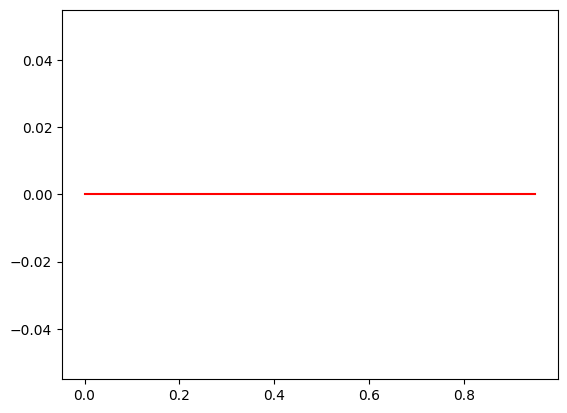

40
40


KeyboardInterrupt: 

In [ ]:
init = 4
spec = 0
cond = 0
velo = 0

M = 10
valx1 = np.zeros(M,dtype=complex)
valx2 = np.zeros(M,dtype=complex)
valx3 = np.zeros(M,dtype=complex)
valx4 = np.zeros(M,dtype=complex)
valx5 = np.zeros(M,dtype=complex)
valex = np.zeros(M,dtype=complex)
H = np.zeros(M)



espaco_ex = Dominio_espaco(a=0,b = 1,del_h = 0.1/(2*(2**(12))))
x_ex = np.arange(espaco_ex.a,espaco_ex.b,espaco_ex.del_h)
condicao_initial_ex = cond_initial(cond = cond,dom_esp = espaco_ex)

if init == 0 and spec == 0 and cond == 0 and velo == 0:
  sol_ex = condicao_initial_ex.cond_inicial(x=x_ex-(np.sqrt(2)))*np.exp(-1)
elif init == 1 and spec == 0 and cond == 0 and velo == 0:
  sol_ex = condicao_initial_ex.cond_inicial(x=x_ex-(np.sqrt(2)))*np.exp(-1)
elif init == 2 and spec == 0 and cond == 0 and velo == 0:
  L = espaco_ex.b - espaco_ex.a
  kappa = 50 # corrija esse kappa no termo linear
  alpha = 12
  beta = 15
  expo = np.exp(- (alpha*L * np.cos(2 * np.pi *kappa* x_ex / L)) / (2*np.sqrt(2) * np.pi*kappa) - beta)
  expo_i = np.exp(- (alpha*L * np.cos(2 * np.pi *kappa* (x_ex-np.sqrt(2)) / L)) / (2*np.sqrt(2) * np.pi*kappa))
  sol_ex = condicao_initial_ex.cond_inicial(x=x_ex-(np.sqrt(2)))*expo/expo_i

elif init == 3 and spec == 0 and cond == 0 and velo == 0:
  sol_ex = condicao_initial_ex.cond_inicial(x=x_ex-(np.sqrt(2)))
elif init == 3 and spec == 0 and cond == 0 and velo == 2:
  sol_ex = condicao_initial_ex.cond_inicial(x=x_ex-(1))
elif init == 4 and spec == 0 and cond == 0 and velo == 0:
  exp_x = np.exp(-(espaco_ex.b - espaco_ex.a)*np.cos((2*np.pi*x_ex)/(espaco_ex.b - espaco_ex.a))/(2*np.pi*np.sqrt(2)))
  exp_xt = np.exp(-(espaco_ex.b - espaco_ex.a)*np.cos((2*np.pi*(x_ex-np.sqrt(2)))/(espaco_ex.b - espaco_ex.a))/(2*np.pi*np.sqrt(2)))
  sol_ex = condicao_initial_ex.cond_inicial(x=x_ex - np.sqrt(2))*exp_x/exp_xt
elif init == 4 and spec == 0 and cond == 0 and velo == 2:
  exp_x = np.exp(-(espaco_ex.b - espaco_ex.a)*np.cos((2*np.pi*x_ex)/(espaco_ex.b - espaco_ex.a))/(2*np.pi*np.sqrt(1)))
  exp_xt = np.exp(-(espaco_ex.b - espaco_ex.a)*np.cos((2*np.pi*(x_ex-np.sqrt(1)))/(espaco_ex.b - espaco_ex.a))/(2*np.pi*np.sqrt(1)))
  sol_ex = condicao_initial_ex.cond_inicial(x=x_ex - np.sqrt(1))*exp_x/exp_xt
elif init == 5 and spec == 0 and cond == 0 and velo == 0:
  exp_x = np.exp(-(espaco_ex.b - espaco_ex.a)*np.cos((2*np.pi*x_ex)/(espaco_ex.b - espaco_ex.a))/(2*np.pi*np.sqrt(2)))
  exp_xt = np.exp(-(espaco_ex.b - espaco_ex.a)*np.cos((2*np.pi*(x_ex-np.sqrt(2)))/(espaco_ex.b - espaco_ex.a))/(2*np.pi*np.sqrt(2)))
  sol_ex = condicao_initial_ex.cond_inicial(x=x_ex - np.sqrt(2))*exp_x/exp_xt

for i in range(M):
  espaco_it = Dominio_espaco(a=0,b = 1,del_h = 0.1/(2*(2**(i))))
  x_it = np.arange(espaco_it.a,espaco_it.b,espaco_it.del_h)
  condicao_initial_it = cond_initial(cond = cond,dom_esp = espaco_it)
  c_initial = condicao_initial_it.cond_inicial(x = x_it)

  if init == 2 and spec == 1 and cond == 0 and velo == 0:
    spec_1 = 0
    espaco_ex = Dominio_espaco(a=0,b = 1,del_h = 1/((4)*(2**(i+1))+1))
    x_ex = np.arange(espaco_ex.a,espaco_ex.b,espaco_ex.del_h)
    condicao_initial_ex = cond_initial(cond = cond,dom_esp = espaco_ex)

    temp_ex = Dominio_tempo(ti=0,tf=1,del_t=1/(2**(i+6)))
    auxiliar_ex = aux(ini = init,spec = spec_1,dom_esp = espaco_ex,dom_tem = temp_ex)
    lin_ex = linear_term(ini = init,spec = spec_1,dom_esp = espaco_ex,dom_tem = temp_ex, aux = auxiliar_ex)
    non_lin_ex = non_linear_term(ini = init,spec = spec_1,dom_esp = espaco_ex,dom_tem = temp_ex, aux = auxiliar_ex)
    normal_ex = normal_term(ini = init,spec = spec_1,dom_esp = espaco_ex,dom_tem = temp_ex, aux = auxiliar_ex)



    func = RungeKutta44


    u_0_line = condicao_initial_ex.cond_inicial(x=x_ex)

    u_hat_line, k_line = FFT(u_0_line)

    u_f = func(x = u_hat_line,dom_tem = temp_ex, lin = lin_ex,non_lin = non_lin_ex,
              normal = normal_ex)



    N_line = (np.size(u_f[-1,:])-1)//2
    k = np.zeros(len(u_f[-1,:]), dtype = int)
    u_trunc,k_trunc = trunc_f(u_f[-1,:],k,N_line)



    sol_ex = IFFT(u_trunc)

    espaco_it = Dominio_espaco(a=0,b = 1,del_h = 1/(2*(2**(i+1))+1))
    x_it = np.arange(espaco_it.a,espaco_it.b,espaco_it.del_h)
    condicao_initial_it = cond_initial(cond = cond,dom_esp = espaco_it)
    c_initial = (condicao_initial_it.cond_inicial(x = x_it))

  temp_it = Dominio_tempo(ti=0,tf=1,del_t=1/(2**(i+1)))
  auxiliar_it = aux(ini = init,spec = spec,dom_esp = espaco_it,dom_tem = temp_it)
  lin_it = linear_term(ini = init,spec = spec,dom_esp = espaco_it,dom_tem = temp_it, aux = auxiliar_it)
  non_lin_it = non_linear_term(ini = init,spec = spec,dom_esp = espaco_it,dom_tem = temp_it, aux = auxiliar_it)
  normal_it = normal_term(ini = init,spec = spec,dom_esp = espaco_it,dom_tem = temp_it, aux = auxiliar_it)
  inter_it = interpol(dom_esp = espaco_it,dom_temp = temp_it)
  find_dep_it = find_departure(dom_esp = espaco_it, dom_temp = temp_it, cond = cond)
  vel_it = perf_vel(espaco_it,temp_it,cond,velo = velo)


  H[i] = temp_it.del_t


  x1 = SLEX_unificado(x=x_it,espaco = espaco_it,tempo=temp_it,cond_init=condicao_initial_it,
           lin = lin_it, non_lin = non_lin_it, normal = normal_it,
          inter_met = inter_it.P3, inter_ad = inter_it.P1,
           find_dep = find_dep_it.SETTLS, vel = vel_it.vel_const)
  x2 = SLED1_unificado(x=x_it,espaco = espaco_it,tempo=temp_it,cond_init=condicao_initial_it,
           lin = lin_it, non_lin = non_lin_it, normal = normal_it,
          inter_met = inter_it.P3, inter_ad = inter_it.P1,
           find_dep = find_dep_it.SETTLS, vel = vel_it.vel_const)
  x3 = SLED2_unificado(x=x_it,espaco = espaco_it,tempo=temp_it,cond_init=condicao_initial_it,
          lin = lin_it, non_lin = non_lin_it, normal = normal_it,
          inter_met = inter_it.P3, inter_ad = inter_it.P1,
           find_dep = find_dep_it.SETTLS, vel = vel_it.vel_const)
  x4 = SE21_unificado(x=x_it,espaco = espaco_it,tempo=temp_it,cond_init=condicao_initial_it,
           lin = lin_it, non_lin = non_lin_it, normal = normal_it,
          inter_met = inter_it.P3, inter_ad = inter_it.P1,
           find_dep = find_dep_it.SETTLS, vel = vel_it.vel_const)
  x5 = SE22_unificado(x=x_it,espaco = espaco_it,tempo=temp_it,cond_init=condicao_initial_it,
           lin = lin_it, non_lin = non_lin_it, normal = normal_it,
          inter_met = inter_it.P3, inter_ad = inter_it.P1,
           find_dep = find_dep_it.SETTLS, vel = vel_it.vel_const)




  x6 = condicao_initial_it.cond_inicial(x = x_it-2**0.5)

  if init == 2 and spec == 1 and cond == 0 and velo == 0:
    sol_ex_reestruct = sol_ex
  else:
    sol_ex_reestruct = auxiliar_it.reestrut(n = int(2**12/2**(i)),x_i = x1, x = sol_ex)

  #plt.plot(x_it,x1.real,color = 'g')
  #plt.plot(x_it,x6,color = 'k')
  print(len(x_it))
  print(len(sol_ex_reestruct))
  #plt.plot(x_it,sol_ex_reestruct.real)
  plt.plot(x_it,x2-x3.real,color = 'r')
  plt.show()


  valx1[i] = auxiliar_it.erro2(x1,sol_ex_reestruct,espaco_it.del_h)
  valx2[i] = auxiliar_it.erro2(x2,sol_ex_reestruct,espaco_it.del_h)
  valx3[i] = auxiliar_it.erro2(x3,sol_ex_reestruct,espaco_it.del_h)
  valx4[i] = auxiliar_it.erro2(x4,sol_ex_reestruct,espaco_it.del_h)
  valx5[i] = auxiliar_it.erro2(x5,sol_ex_reestruct,espaco_it.del_h)




In [ ]:
plt.xscale('log')
plt.plot(H,valx5.real-valx4.real,'-o',label = 'SLEX')

In [ ]:

#plt.plot(H,valx1.real,'-o',label = 'SLEX')
plt.plot(H,valx2.real,'-o',label = 'SE11')
plt.plot(H,valx3.real,'-o',label = 'SE12')
plt.plot(H,valx4.real,'-o',label = 'SE21')
plt.plot(H,valx5.real,'-o',label = 'SE22')
plt.loglog()

plt.xlabel('Δ t',fontsize = 14)
plt.ylabel('Error',fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=12)



if init == 0 and spec == 0 and cond == 0 and velo == 0:
  h1_ord1 = 10**(-2)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(2*10**(-6))


  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,3)

  #não iremos fazer pois é igual ao teste 1 e 2
  #plt.title('Linear forcing test 3', fontsize = 16)
  plt.legend()

elif init == 1 and spec == 0 and cond == 0 and velo == 0:
  h1_ord1 = 10**(-2)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(2*10**(-3))

  h1_ord2 = 10**(-2)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(10**(-5))


  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)

  plt.title('Linear forcing test 3', fontsize = 16)
  plt.legend()

elif init == 2 and spec == 1 and cond == 0 and velo == 0:

  h1_ord1 = 10**(-2)
  h2_ord1 = 3*h1_ord1
  e_ord1 = 2*np.min(10**(-3))

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)

  h1_ord2 = 10**(-2)
  h2_ord2 = 3*h1_ord1
  e_ord2 = 1*np.min(10**(-5))

  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)


  plt.title('Linear forcing test 6', fontsize = 16)
  plt.legend()

elif init == 3 and spec == 0 and cond == 0 and velo == 0:

  h1_ord1 = 10**(-2)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(10**(-8))

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,3)


  plt.title('Linear forcing test 1', fontsize = 16)
  plt.legend()

elif init == 3 and spec == 0 and cond == 0 and velo == 2:




  plt.title('Linear forcing test 2', fontsize = 16)
  plt.legend()

elif init == 4 and spec == 0 and cond == 0 and velo == 0:

  h1_ord1 = 10**(-2)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(10**(-5))

  h1_ord2 = 10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(10**(-3))


  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,2)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,1)


  plt.title('Linear forcing test 4', fontsize = 16)
  plt.legend()

elif init == 5 and spec == 0 and cond == 0 and velo == 0:

  h1_ord1 = 10**(-2)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(10**(-5))

  h1_ord2 = 5*10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(3*10**(-3))


  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,2)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,1)


  plt.title('Linear forcing test 5', fontsize = 16)
  plt.legend()

plt.legend()

print(valx2)

##comparar Burgers para semi-lagrangiano

In [ ]:
init = 6
spec = 1
velo = 0

N = 10

Erro = np.zeros([3,N])
H_2  = np.zeros([3,N])

for j in range(3):
  cond = j #para determinar a função seno que não dá problema
  for i in range(N):
    M_spec = 2**(i)         # número de frequencias no espectral final
    espaco_ref = Dominio_espaco(a=0,b = 1,del_h = 1/(4*M_spec + 1))
    x_ref = np.arange(espaco_ref.a,espaco_ref.b,espaco_ref.del_h)
    condicao_initial_ref = cond_initial(cond = cond,dom_esp = espaco_ref)

    temp_ref = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(i)))
    auxiliar_ref = aux(ini = init,spec = spec,dom_esp = espaco_ref,dom_tem = temp_ref)
    lin_ref = linear_term(ini = init,spec = spec,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
    non_lin_ref = non_linear_term(ini = init,spec = spec,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
    normal_ref = normal_term(ini = init,spec = spec,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)



    func = RungeKutta44


    u_0_line = condicao_initial_ref.cond_inicial(x=x_ref)

    u_hat_line, k_line = FFT(u_0_line)

    u_f = func(x = u_hat_line,dom_tem = temp_ref, lin = lin_ref,non_lin = non_lin_ref,
              normal = normal_ref)



    N_line = (np.size(u_f[-1,:])-1)//2
    k = np.zeros(len(u_f[-1,:]), dtype = int)
    u_trunc,k_trunc = trunc_f(u_f[-1,:],k,N_line)



    u_sol = IFFT(u_trunc)
    ##############################################################################################
    ################## Até aqui fizemos a solução exata que será usada para parametrizar##########
    ##############################################################################################


    espaco_semilag = Dominio_espaco(a=0,b = 1,del_h = 1/(2*M_spec+1))
    x_semilag = np.arange(espaco_semilag.a,espaco_semilag.b,espaco_semilag.del_h)
    condicao_initial_semilag = cond_initial(cond = cond,dom_esp = espaco_semilag)

    temp_semilag = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(i)))
    auxiliar_semilag = aux(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag)
    lin_semilag = linear_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
    non_lin_semilag = non_linear_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
    normal_semilag = normal_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
    inter_semilag = interpol(dom_esp = espaco_semilag,dom_temp = temp_semilag)
    find_dep_semilag = find_departure(dom_esp = espaco_semilag, dom_temp = temp_semilag, cond = cond)
    vel_semilag = perf_vel(espaco_semilag,temp_semilag,cond,velo = velo)


    x1 = Burgers1(dom_esp = espaco_semilag,dom_temp=temp_semilag,inter_met=inter_semilag.P3,
                  find_d = find_dep_semilag.SETTLS,inter_ad = inter_semilag.P1,
                  cond = condicao_initial_semilag.cond_inicial(x=x_semilag),
                  vel_0 = condicao_initial_semilag.cond_inicial(x=x_semilag),x_i = x_semilag)

    H_2[j,i] = temp_semilag.del_t
    Erro[j,i] = auxiliar_semilag.erro2(x1,u_sol,espaco_semilag.del_h)
  plt.title("Solution of Inviscid Burger Equation with")
  plt.plot(x_semilag,x1)



In [ ]:
plt.title("Error x Δ t - Cubic Interolation", fontsize = 16)
plt.xlabel('Δ t',fontsize = 14)
plt.ylabel('Error',fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=12)

plt.plot(H_2[0,:],Erro[0,:],'o-', label = 'Sine')
plt.plot(H_2[1,:],Erro[1,:],'o-', label = 'Gaussian')
plt.plot(H_2[2,:],Erro[2,:],'o-', label = 'Triangular')
plt.legend()
plt.loglog()


if init == 6 and spec == 1 and velo == 0:
  h1_ord1 = 10**(-4)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(10**(-4))

  h1_ord2 = 10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = 5*10**-6

  h1_ord3 = 10**(-5)
  h2_ord3 = 3*h1_ord3
  e_ord3 = 2*10**-9

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,3)
  ord3 = graf_ordem(h1_ord3,h2_ord3,e_ord3,2)

elif init == 2 and spec == 1 and velo == 0:
  h1_ord1 = 10**(-4)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(10**(-4))

  h1_ord2 = 10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = 10**-5

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,3)

# Aqui, iremos testar burgers para os Semi-Lagrangeanos Exponenciais

init = 6, spec = 1, cond = 0 and velo = 0 ==> Teste 8 (burger sem forçante - para integrador exponencial)

init = 6, spec = 0, cond = 0 and velo = 0 ==> Teste 8 (burger sem forçante - para SL-EXP)

init = 7, spec = 0, cond = 0 and velo = 0 ==> Teste 9 (burger forçante linear sin SL-EXP)

init = 7, spec = 1, cond = 0 and velo = 0 ==> Teste 9 (burger forçante linear sin)

init = 8, spec = 1, cond = 0 and velo = 0 ==> Teste 10 (burger forçante não linear constante)

init = 9, spec = 1, cond = 0 and velo = 0 ==> Teste 11 (burger com viscodade - para integrador exponencial)

init = 10,spec = 1, cond = 0 and velo = 0 ==> Teste 11 (burger com viscosidade - para SL-EXP)

init = 11, spec = 1, cond = 0 and velo = 0 ==> Teste 12 (burger com viscodade - para integrador exponencial não linearidade quadrática)

init = 12,spec = 1, cond = 0 and velo = 0 ==> Teste 12 (burger com viscosidade - para SL-EXP não linearidade quadrática)

In [ ]:
### Esses indices _ref são para determinar o problema para a determinação de uma solução de referencia via pseudo spectral

init_ref = 7
spec_ref = 1
cond_ref = 0
velo_ref = 0

N = 12
valx1 = np.zeros(N,dtype=complex)
valx2 = np.zeros(N,dtype=complex)
valx3 = np.zeros(N,dtype=complex)
valx4 = np.zeros(N,dtype=complex)
valx5 = np.zeros(N,dtype=complex)

H_3  = np.zeros(N)


for i in range(N):
  M_spec = 2**(i+1)         # determina a malha final no processo pseudospectral
  espaco_ref = Dominio_espaco(a=0,b = 1,del_h = 1/(4*M_spec + 1))
  x_ref = np.arange(espaco_ref.a,espaco_ref.b,espaco_ref.del_h)
  condicao_initial_ref = cond_initial(cond = cond_ref,dom_esp = espaco_ref)

  temp_ref = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(i+6)))
  auxiliar_ref = aux(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref)
  lin_ref = linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  non_lin_ref = non_linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  normal_ref = normal_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)



  func = RungeKutta44


  u_0_line = condicao_initial_ref.cond_inicial(x=x_ref)

  u_hat_line, k_line = FFT(u_0_line)

  u_f = func(x = u_hat_line,dom_tem = temp_ref, lin = lin_ref,non_lin = non_lin_ref,
              normal = normal_ref)



  N_line = (np.size(u_f[-1,:])-1)//2
  k = np.zeros(len(u_f[-1,:]), dtype = int)
  u_trunc,k_trunc = trunc_f(u_f[-1,:],k,N_line)



  u_sol = IFFT(u_trunc)
    ##############################################################################################
    ################## Até aqui fizemos a solução exata que será usada para parametrizar##########
    ##############################################################################################

  init = 7
  spec = 0
  cond = 0
  velo = 0

  espaco_semilag = Dominio_espaco(a=0,b = 1,del_h = 1/(2*M_spec + 1))
  x_semilag = np.arange(espaco_semilag.a,espaco_semilag.b,espaco_semilag.del_h)
  condicao_initial_semilag = cond_initial(cond = cond,dom_esp = espaco_semilag)

  temp_semilag = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(i)))
  auxiliar_semilag = aux(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag)
  lin_semilag = linear_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  non_lin_semilag = non_linear_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  normal_semilag = normal_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  inter_semilag = interpol(dom_esp = espaco_semilag,dom_temp = temp_semilag)
  find_dep_semilag = find_departure(dom_esp = espaco_semilag, dom_temp = temp_semilag, cond = cond)
  vel_semilag = perf_vel(espaco_semilag,temp_semilag,cond,velo = velo)

  print(i)


  x1 = SLEX_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x2 = SLED1_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x3 = SLED2_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x4 = SE21_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x5 = SE22_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)


  H_3[i] = temp_semilag.del_t
  valx1[i] = auxiliar_semilag.erro2(x1,u_sol,espaco_semilag.del_h)
  valx2[i] = auxiliar_semilag.erro2(x2,u_sol,espaco_semilag.del_h)
  valx3[i] = auxiliar_semilag.erro2(x3,u_sol,espaco_semilag.del_h)
  valx4[i] = auxiliar_semilag.erro2(x4,u_sol,espaco_semilag.del_h)
  valx5[i] = auxiliar_semilag.erro2(x5,u_sol,espaco_semilag.del_h)



In [ ]:
plt.plot(x1)
plt.plot(u_sol,color = 'g')
plt.plot(x5)

print(valx1)

In [ ]:


#plt.plot(H_3,valx1,'o-',label = 'SLEX')
plt.plot(H_3,valx2,'o-',label = 'SE11')
plt.plot(H_3,valx3,'o-',label = 'SE12')
plt.plot(H_3,valx4,'o-',label = 'SE21')
plt.plot(H_3,valx5,'o-',label = 'SE22')
plt.legend()
plt.loglog()

plt.xlabel('Δ t',fontsize = 14)
plt.ylabel('Error',fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=12)

if init == 6 and spec == 0 and velo == 0:
  plt.title("Error x Δ t - Burger equation", fontsize = 16)
  h1_ord1 = 10**(-3)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(10**(-5))


  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,2)
elif init == 7 and spec == 0 and velo == 0:
  plt.title("Error x Δ t - Burger with Linear forcing - sine", fontsize = 16)
  h1_ord1 = 10**(-4)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(6*10**(-5))

  h1_ord2 = 10**(-4)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(9*10**(-7))

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)

elif init == 8 and spec == 0 and velo == 0:
  plt.title("Error x Δ t - Burger with Linear forcing - constant", fontsize = 16)
  h1_ord1 = 10**(-4)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(10**(-6))


  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,2)

elif init == 10 and spec == 1 and velo == 0:
  plt.title("Error x Δ t - Burger with Stiff Linear forcing", fontsize = 16)
  h1_ord1 = 1.5*10**(-3)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(3*10**-4)

  h1_ord2 = 1.5*10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(10**-5)

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)

elif init == 12 and spec == 1 and velo == 0:
  plt.title("Error x Δ t - Burger with Stiff Linear forcing", fontsize = 16)
  h1_ord1 = 1.5*10**(-3)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(3*10**-4)



  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)



In [ ]:
plt.plot(H_2[0,:],Erro[0,:],'o-', label = 'Sine')
plt.plot(H_3,valx5,'o-',label = 'SE22')
plt.legend()
plt.loglog()

#Comparação entre os integradores exponenciais e integradores semi-Lagrangeanos exponenciais

init = 7, spec = 0, cond = 0 and velo = 0 ==> Teste 9 (burger forçante linear sin SL-EXP)

init = 7, spec = 1, cond = 0 and velo = 0 ==> Teste 9 (burger forçante linear sin)

init = 9, spec = 1, cond = 0 and velo = 0 ==> Teste 11 (burger com viscodade - para integrador exponencial)

init = 10,spec = 1, cond = 0 and velo = 0 ==> Teste 11 (burger com viscosidade - para SL-EXP)

init = 11, spec = 1, cond = 0 and velo = 0 ==> Teste 12 (burger com viscodade - para integrador exponencial não linearidade quadrática)

init = 12,spec = 1, cond = 0 and velo = 0 ==> Teste 12 (burger com viscosidade - para SL-EXP não linearidade quadrática)

In [ ]:
### Esses indices _ref são para determinar o problema para a determinação de uma solução de referencia via pseudo spectral

init_ref = 7
spec_ref = 1
cond_ref = 0
velo_ref = 0

N = 12
valx1 = np.zeros(N,dtype=complex)
valx2 = np.zeros(N,dtype=complex)
valx3 = np.zeros(N,dtype=complex)
valx4 = np.zeros(N,dtype=complex)
valx5 = np.zeros(N,dtype=complex)
valx6 = np.zeros(N,dtype=complex)
valx7 = np.zeros(N,dtype=complex)

H_3  = np.zeros(N)


for i in range(N):
  M_spec = 2**(i+1)         # determina a malha final no processo pseudospectral
  espaco_ref = Dominio_espaco(a=0,b = 1,del_h = 1/(4*M_spec + 1))
  x_ref = np.arange(espaco_ref.a,espaco_ref.b,espaco_ref.del_h)
  condicao_initial_ref = cond_initial(cond = cond_ref,dom_esp = espaco_ref)

  temp_ref = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(16)))
  auxiliar_ref = aux(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref)
  lin_ref = linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  non_lin_ref = non_linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  normal_ref = normal_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)



  func_ref = RungeKutta44
  func_ie1 = Euler_Exp_Explicito
  func_ie2 = RK2_Exp_Explicito1



  u_0_line = condicao_initial_ref.cond_inicial(x=x_ref)

  u_hat_line, k_line = FFT(u_0_line)

  u_f = func_ref(x = u_hat_line,dom_tem = temp_ref, lin = lin_ref,non_lin = non_lin_ref,
              normal = normal_ref)
  N_line = (np.size(u_f[-1,:]))//2
  k = np.zeros(len(u_f[-1,:]), dtype = int)
  u_trunc,k_trunc = trunc_f(u_f[-1,:],k,N_line)
  ##############################################################
  ##############################################################
  temp_ref = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(i)))
  auxiliar_ref = aux(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref)
  lin_ref = linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  non_lin_ref = non_linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  normal_ref = normal_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)


  u_f1 = func_ie1(x = u_hat_line,dom_tem = temp_ref, lin = lin_ref,non_lin = non_lin_ref,
              normal = normal_ref)

  u_f2 = func_ie2(x = u_hat_line,dom_tem = temp_ref, lin = lin_ref,non_lin = non_lin_ref,
              normal = normal_ref)


  N_line = (np.size(u_f[-1,:])-1)//2
  k = np.zeros(len(u_f[-1,:]), dtype = int)
  u_trunc1,k_trunc = trunc_f(u_f1[-1,:],k,N_line)
  u_trunc2,k_trunc = trunc_f(u_f2[-1,:],k,N_line)


  u_sol = IFFT(u_trunc)
  u_sol1 = IFFT(u_trunc1)
  u_sol2 = IFFT(u_trunc2)
  if i == 3:
    x_spac1 = np.arange(0,1,1/(2*M_spec +1))
    u1 = np.copy(u_sol1)
  if i==5:
    x_spac2 = np.arange(0,1,1/(2*M_spec +1))
    u2 = np.copy(u_sol1)
    ##############################################################################################
    ################## Até aqui fizemos a solução exata que será usada para parametrizar##########
    ##############################################################################################

  init = 7
  spec = 0
  cond = 0
  velo = 0

  espaco_semilag = Dominio_espaco(a=0,b = 1,del_h = 1/(2*M_spec + 1))
  x_semilag = np.arange(espaco_semilag.a,espaco_semilag.b,espaco_semilag.del_h)
  condicao_initial_semilag = cond_initial(cond = cond,dom_esp = espaco_semilag)

  temp_semilag = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(i)))
  auxiliar_semilag = aux(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag)
  lin_semilag = linear_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  non_lin_semilag = non_linear_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  normal_semilag = normal_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  inter_semilag = interpol(dom_esp = espaco_semilag,dom_temp = temp_semilag)
  find_dep_semilag = find_departure(dom_esp = espaco_semilag, dom_temp = temp_semilag, cond = cond)
  vel_semilag = perf_vel(espaco_semilag,temp_semilag,cond,velo = velo)

  print(i)


  x1 = SLEX_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x2 = SLED1_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x3 = SLED2_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x4 = SE21_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x5 = SE22_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)


  H_3[i] = temp_semilag.del_t
  valx1[i] = auxiliar_semilag.erro2(x1,u_sol,espaco_semilag.del_h)
  valx2[i] = auxiliar_semilag.erro2(x2,u_sol,espaco_semilag.del_h)
  valx3[i] = auxiliar_semilag.erro2(x3,u_sol,espaco_semilag.del_h)
  valx4[i] = auxiliar_semilag.erro2(x4,u_sol,espaco_semilag.del_h)
  valx5[i] = auxiliar_semilag.erro2(x5,u_sol,espaco_semilag.del_h)
  valx6[i] = auxiliar_semilag.erro2(u_sol1,u_sol,espaco_semilag.del_h)
  valx7[i] = auxiliar_semilag.erro2(u_sol2,u_sol,espaco_semilag.del_h)


0
1


/tmp/ipykernel_741/3564725725.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = (np.arange(n) - p.astype(int)) % n


2
3
4
5
6
7


/tmp/ipykernel_741/620815826.py:87: RuntimeWarning: overflow encountered in multiply
  w_real = -IFFT(x_redef)*IFFT(x_deriv) +(- np.sin(2*np.pi*x_new/(self.dom_esp.b - self.dom_esp.a)))*IFFT(x)
/usr/local/lib/python3.12/dist-packages/numpy/fft/_pocketfft.py:94: RuntimeWarning: invalid value encountered in fft
  return ufunc(a, fct, axes=[(axis,), (), (axis,)], out=out)


8
9
10


KeyboardInterrupt: 

In [ ]:
plt.plot(x_spac2,u2, label = 'unstable solution - i=5')
plt.plot(x_spac1,u1, label = "stable solution - i=3")
plt.title('Solution Inviscid Burger Equation - ETDRK1', fontsize = 16)
plt.legend()
plt.xlabel('x',fontsize = 14)
plt.ylabel('u',fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=12)


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


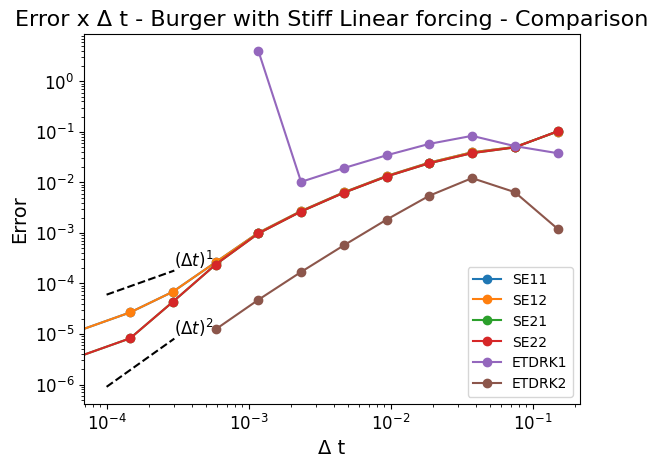

In [50]:


#plt.plot(H_3,valx1,'o-',label = 'SLEX')
plt.plot(H_3,valx2,'o-',label = 'SE11')
plt.plot(H_3,valx3,'o-',label = 'SE12')
plt.plot(H_3,valx4,'o-',label = 'SE21')
plt.plot(H_3,valx5,'o-',label = 'SE22')
plt.plot(H_3,valx6,'o-',label = 'ETDRK1')
plt.plot(H_3,valx7,'o-',label = 'ETDRK2')
plt.legend()
plt.loglog()

plt.xlabel('Δ t',fontsize = 14)
plt.ylabel('Error',fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=12)


if init == 7 and spec == 0 and velo == 0:
  plt.title("Error x Δ t - Burger with Stiff Linear forcing - Comparison", fontsize = 16)
  h1_ord1 = 10**(-4)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(6*10**(-5))

  h1_ord2 = 10**(-4)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(9*10**(-7))

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)


elif init == 10 and spec == 1 and velo == 0:
  plt.title("Error x Δ t - Burger with Stiff Linear forcing - Comparison", fontsize = 16)
  h1_ord1 = 1.5*10**(-3)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(3*10**-4)

  h1_ord2 = 1.5*10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(10**-5)

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)

elif init == 12 and spec == 1 and velo == 0:
  plt.title("Error x Δ t - Burger with Stiff Linear forcing - Comparison", fontsize = 16)
  h1_ord1 = 1.5*10**(-3)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(3*10**-4)

  h1_ord2 = 1.5*10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(10**-5)


  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)


#Comparação entre os integradores exponenciais e integradores semi-Lagrangeanos exponenciais com $\Delta x$ fixo e $\Delta t$ variável

init = 7, spec = 0, cond = 0 and velo = 0 ==> Teste 9 (burger forçante linear sin SL-EXP)

init = 7, spec = 1, cond = 0 and velo = 0 ==> Teste 9 (burger forçante linear sin)

init = 9, spec = 1, cond = 0 and velo = 0 ==> Teste 11 (burger com viscodade - para integrador exponencial)

init = 10,spec = 1, cond = 0 and velo = 0 ==> Teste 11 (burger com viscosidade - para SL-EXP)

init = 11, spec = 1, cond = 0 and velo = 0 ==> Teste 12 (burger com viscodade - para integrador exponencial não linearidade quadrática)

init = 12,spec = 1, cond = 0 and velo = 0 ==> Teste 12 (burger com viscosidade - para SL-EXP não linearidade quadrática)

In [ ]:
### Esses indices _ref são para determinar o problema para a determinação de uma solução de referencia via pseudo spectral

init_ref = 7
spec_ref = 1
cond_ref = 0
velo_ref = 0

N = 12
valx1 = np.zeros(N,dtype=complex)
valx2 = np.zeros(N,dtype=complex)
valx3 = np.zeros(N,dtype=complex)
valx4 = np.zeros(N,dtype=complex)
valx5 = np.zeros(N,dtype=complex)
valx6 = np.zeros(N,dtype=complex)
valx7 = np.zeros(N,dtype=complex)

H_3  = np.zeros(N)


for i in range(N):
  M_spec = 2**(5+2)         # numero de modos que serão representados no final
  espaco_ref = Dominio_espaco(a=0,b = 1,del_h = 1/(4*M_spec + 1))
  x_ref = np.arange(espaco_ref.a,espaco_ref.b,espaco_ref.del_h)
  condicao_initial_ref = cond_initial(cond = cond_ref,dom_esp = espaco_ref)

  temp_ref = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(16)))
  auxiliar_ref = aux(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref)
  lin_ref = linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  non_lin_ref = non_linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  normal_ref = normal_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)



  func_ref = RungeKutta44
  func_ie1 = Euler_Exp_Explicito
  func_ie2 = RK2_Exp_Explicito1



  u_0_line = condicao_initial_ref.cond_inicial(x=x_ref)

  u_hat_line, k_line = FFT(u_0_line)

  u_f = func_ref(x = u_hat_line,dom_tem = temp_ref, lin = lin_ref,non_lin = non_lin_ref,
              normal = normal_ref)
  N_line = (np.size(u_f[-1,:]))//2
  k = np.zeros(len(u_f[-1,:]), dtype = int)
  u_trunc,k_trunc = trunc_f(u_f[-1,:],k,N_line)
  ##############################################################
  ##############################################################
  temp_ref = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(i)))
  auxiliar_ref = aux(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref)
  lin_ref = linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  non_lin_ref = non_linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  normal_ref = normal_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)


  u_f1 = func_ie1(x = u_hat_line,dom_tem = temp_ref, lin = lin_ref,non_lin = non_lin_ref,
              normal = normal_ref)

  u_f2 = func_ie2(x = u_hat_line,dom_tem = temp_ref, lin = lin_ref,non_lin = non_lin_ref,
              normal = normal_ref)


  N_line = (np.size(u_f[-1,:])-1)//2
  k = np.zeros(len(u_f[-1,:]), dtype = int)
  u_trunc1,k_trunc = trunc_f(u_f1[-1,:],k,N_line)
  u_trunc2,k_trunc = trunc_f(u_f2[-1,:],k,N_line)


  u_sol = IFFT(u_trunc)
  u_sol1 = IFFT(u_trunc1)
  u_sol2 = IFFT(u_trunc2)
    ##############################################################################################
    ################## Até aqui fizemos a solução exata que será usada para parametrizar##########
    ##############################################################################################

  init = 7
  spec = 0
  cond = 0
  velo = 0

  espaco_semilag = Dominio_espaco(a=0,b = 1,del_h = 1/(2*M_spec + 1))
  x_semilag = np.arange(espaco_semilag.a,espaco_semilag.b,espaco_semilag.del_h)
  condicao_initial_semilag = cond_initial(cond = cond,dom_esp = espaco_semilag)

  temp_semilag = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(i)))
  auxiliar_semilag = aux(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag)
  lin_semilag = linear_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  non_lin_semilag = non_linear_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  normal_semilag = normal_term(ini = init,spec = spec,dom_esp = espaco_semilag,dom_tem = temp_semilag, aux = auxiliar_semilag)
  inter_semilag = interpol(dom_esp = espaco_semilag,dom_temp = temp_semilag)
  find_dep_semilag = find_departure(dom_esp = espaco_semilag, dom_temp = temp_semilag, cond = cond)
  vel_semilag = perf_vel(espaco_semilag,temp_semilag,cond,velo = velo)

  print(i)


  x1 = SLEX_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x2 = SLED1_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x3 = SLED2_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x4 = SE21_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)
  x5 = SE22_unificado(x=x_semilag ,espaco = espaco_semilag ,tempo=temp_semilag ,cond_init=condicao_initial_semilag ,
           lin = lin_semilag , non_lin = non_lin_semilag , normal = normal_semilag,
          inter_met = inter_semilag.P3, inter_ad = inter_semilag.P1,
           find_dep = find_dep_semilag.SETTLS, vel = vel_semilag.vel_const, linear = False)

  if i==5:
    plt.title("Burger equation with  sinusoidal forcing - $\Delta t = 0.15/2^5$")
    plt.plot(x_semilag,x5,'o-',label = 'SE22')
    plt.plot(x_semilag,u_sol1,label = 'ETDRK1')
    plt.plot(x_semilag,u_sol2,label = 'ETDRK2')
    plt.legend()
    plt.show()

  elif i==11:
    plt.title("Burger equation with  sinusoidal forcing - $\Delta t = 0.15/2^{11}$")
    plt.plot(x_semilag,x5,'o-',label = 'SE22')
    plt.plot(x_semilag,u_sol1,'o-',label = 'ETDRK1')
    plt.plot(x_semilag,u_sol2,'o-',label = 'ETDRK2')
    plt.legend()
    plt.show()

  H_3[i] = temp_semilag.del_t
  valx1[i] = auxiliar_semilag.erro2(x1,u_sol,espaco_semilag.del_h)
  valx2[i] = auxiliar_semilag.erro2(x2,u_sol,espaco_semilag.del_h)
  valx3[i] = auxiliar_semilag.erro2(x3,u_sol,espaco_semilag.del_h)
  valx4[i] = auxiliar_semilag.erro2(x4,u_sol,espaco_semilag.del_h)
  valx5[i] = auxiliar_semilag.erro2(x5,u_sol,espaco_semilag.del_h)
  valx6[i] = auxiliar_semilag.erro2(u_sol1,u_sol,espaco_semilag.del_h)
  valx7[i] = auxiliar_semilag.erro2(u_sol2,u_sol,espaco_semilag.del_h)



In [ ]:
print(valx1)
print(valx2)
print(valx3)
print(valx4)
print(valx5)
print(valx6)
print(valx7)

In [ ]:


#plt.plot(H_3,valx1,'o-',label = 'SLEX')
plt.plot(H_3,valx2,'o-',label = 'SE11')
plt.plot(H_3,valx3,'o-',label = 'SE12')
plt.plot(H_3,valx4,'o-',label = 'SE21')
plt.plot(H_3,valx5,'o-',label = 'SE22')
plt.plot(H_3,valx6,'o-',label = 'ETDRK1')
plt.plot(H_3,valx7,'o-',label = 'ETDRK2')
plt.ylim(10**-8,10)
plt.legend()
plt.loglog()

plt.xlabel('Δ t',fontsize = 14)
plt.ylabel('Error',fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=12)


if init == 7 and spec == 0 and velo == 0:
  plt.title("Error x Δ t - Burger with Stiff Linear forcing - Comparison", fontsize = 16)
  h1_ord1 = 10**(-4)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(6*10**(-5))

  h1_ord2 = 10**(-4)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(9*10**(-7))

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)


elif init == 10 and spec == 1 and velo == 0:
  plt.title("Error x Δ t - Burger with Stiff Linear forcing - Comparison", fontsize = 16)
  h1_ord1 = 1.5*10**(-3)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(3*10**-4)

  h1_ord2 = 1.5*10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(10**-5)

  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)

elif init == 12 and spec == 1 and velo == 0:
  plt.title("Error x Δ t - Burger with Stiff Linear forcing - Comparison", fontsize = 16)
  h1_ord1 = 1.5*10**(-3)
  h2_ord1 = 3*h1_ord1
  e_ord1 = np.min(3*10**-4)

  h1_ord2 = 1.5*10**(-3)
  h2_ord2 = 3*h1_ord2
  e_ord2 = np.min(10**-5)


  ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1)
  ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)


In [ ]:
tilde_x1,k = FFT(x1)
tilde_x2,k = FFT(x2)
tilde_x3,k = FFT(x3)
tilde_x4,k = FFT(x4)
tilde_x5,k = FFT(x5)




x_ini,_ = trunc_f(u_hat_line,k,N_line)


x_ini = np.fft.fftshift(np.abs(x_ini))



tilde_x1 = np.fft.fftshift(np.abs(tilde_x1))
tilde_x2 = np.fft.fftshift(np.abs(tilde_x2))
tilde_x3 = np.fft.fftshift(np.abs(tilde_x3))
tilde_x4 = np.fft.fftshift(np.abs(tilde_x4))
tilde_x5 = np.fft.fftshift(np.abs(tilde_x5))
k = np.fft.fftshift(k)

plt.plot(k,tilde_x1,label = 'x1')
plt.plot(k,tilde_x2,label = 'x2')
plt.plot(k,tilde_x3,label = 'x3')
plt.plot(k,tilde_x4,label = 'x4')
plt.plot(k,tilde_x5,label = 'x5')
plt.plot(k,x_ini)
plt.legend()

plt.loglog()

#Verificação de ordem da Solução de referência

In [ ]:
def trunc_f_SWE(U):
  u,v,h = desmontar_U(U)

  M_spec = int((len(u)-1)/4)
  N_line = 2*M_spec

  u_tilde,k_tilde = FFT(u)
  v_tilde,_ = FFT(v)
  h_tilde,_ = FFT(h)

  u_trunc,_ = trunc_f(u_tilde,k_tilde,N_line)
  v_trunc,_ = trunc_f(v_tilde,k_tilde,N_line)
  h_trunc,_ = trunc_f(h_tilde,k_tilde,N_line)

  u_sol = IFFT(u_trunc)
  v_sol = IFFT(v_trunc)
  h_sol = IFFT(h_trunc)

  return u_sol,v_sol,h_sol


In [ ]:
def norma_SWE(u,v,h,dx):
  er_u = np.sum((u)**2)*dx
  er_v = np.sum((v)**2)*dx
  er_h = np.sum((h)**2)*dx

  return np.sqrt(er_u + er_v + er_h)

In [ ]:
cond_ref = 0
velo = 0
init_ref = 0
spec_ref = 0


n = 7
H5 = np.zeros(n)
Er_U_1 = np.zeros(n)
Er_U_2 = np.zeros(n)
Er_U_3 = np.zeros(n)
Er_U_4 = np.zeros(n)

for i in range(n):
  M_spec = 2**( 1+i)         # numero de modos representados no final
  espaco_ref = Dominio_espaco(a=0,b = 1,del_h = 1/(4*M_spec + 1))
  x_ref = np.arange(espaco_ref.a,espaco_ref.b,espaco_ref.del_h)
  condicao_initial_ref = cond_initial(cond = cond_ref,dom_esp = espaco_ref)
  temp_ref = Dominio_tempo(ti=0,tf=0.3,del_t=0.15/(2**(7+i)))
  auxiliar_ref = aux(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref)
  lin_ref = linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  non_lin_ref = non_linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  normal_ref = normal_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
  inter_ref = interpol(dom_esp = espaco_ref,dom_temp = temp_ref)
  find_dep_ref = find_departure(dom_esp = espaco_ref, dom_temp = temp_ref, cond = cond_ref)
  vel_ref = perf_vel(espaco_ref,temp_ref,cond = cond_ref,velo = velo)

  ############solução Exata#####################
  x = np.arange(espaco_ref.a,espaco_ref.b,1/(2*M_spec + 1))
  g = 10
  f = 10**0


  u = np.zeros_like(x)
  v = -(g/f)*(2*np.pi/(espaco_ref.b - espaco_ref.a))*np.sin(2*np.pi*x/(espaco_ref.b - espaco_ref.a))
  h = np.cos(2*np.pi*x/(espaco_ref.b - espaco_ref.a))

  plt.plot(x,u)
  plt.plot(x,v)
  plt.plot(x,h)
  plt.show()
  ###################################################################


  U_1 = SLED1_SWE(x = x_ref, espaco = espaco_ref,tempo = temp_ref, cond_init=condicao_initial_ref,
                  lin = lin_ref, non_lin = non_lin_ref, normal = normal_ref,
                  inter_met = inter_ref.P3, inter_ad = inter_ref.P3,find_dep = find_dep_ref.SETTLS,
                  vel = vel_ref.vel_const)
  U_2 = SLED2_SWE(x = x_ref, espaco = espaco_ref,tempo = temp_ref, cond_init=condicao_initial_ref,
                  lin = lin_ref, non_lin = non_lin_ref, normal = normal_ref,
                  inter_met = inter_ref.P3, inter_ad = inter_ref.P3,find_dep = find_dep_ref.SETTLS,
                  vel = vel_ref.vel_const)
  U_3 = SE21_SWE(x = x_ref, espaco = espaco_ref,tempo = temp_ref, cond_init=condicao_initial_ref,
                  lin = lin_ref, non_lin = non_lin_ref, normal = normal_ref,
                  inter_met = inter_ref.P3, inter_ad = inter_ref.P3,find_dep = find_dep_ref.SETTLS,
                  vel = vel_ref.vel_const)
  U_4 = SE22_SWE(x = x_ref, espaco = espaco_ref,tempo = temp_ref, cond_init=condicao_initial_ref,
                  lin = lin_ref, non_lin = non_lin_ref, normal = normal_ref,
                  inter_met = inter_ref.P3, inter_ad = inter_ref.P3,find_dep = find_dep_ref.SETTLS,
                  vel = vel_ref.vel_const)

  u1,v1,h1 = trunc_f_SWE(U_1)
  u2,v2,h2 = trunc_f_SWE(U_2)
  u3,v3,h3 = trunc_f_SWE(U_3)
  u4,v4,h4 = trunc_f_SWE(U_4)


  H5[i] = temp_ref.del_t

  Er_U_1[i] = norma_SWE(u1,(v1 - v)/np.max(v),h1 - h,1/(2*M_spec + 1))
  Er_U_2[i] = norma_SWE(u2,(v2 - v)/np.max(v),h2 - h,1/(2*M_spec + 1))
  Er_U_3[i] = norma_SWE(u3,(v3 - v)/np.max(v),h3 - h,1/(2*M_spec + 1))
  Er_U_4[i] = norma_SWE(u4,(v4 - v)/np.max(v),h4 - h,1/(2*M_spec + 1))



In [ ]:
plt.loglog()

plt.title('Error SWE - Geostrophic waves', fontsize = 16)

plt.plot(H5,Er_U_1,'-o', label = 'SE11')
plt.plot(H5,Er_U_2,'-o', label = 'SE12')
plt.plot(H5,Er_U_3,'-o', label = 'SE21')
plt.plot(H5,Er_U_4,'-o', label = 'SE22')
plt.legend()

plt.xlabel('Δ t',fontsize = 14)
plt.ylabel('Error',fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=12)

In [ ]:
x = np.arange(espaco_ref.a,espaco_ref.b,1/(2*M_spec + 1))
g = 10
f = 10**-3


u = np.zeros_like(x)
v = -(g/f)*(2*np.pi/(espaco_ref.b - espaco_ref.a))*np.sin(2*np.pi*x/(espaco_ref.b - espaco_ref.a))
h = np.cos(2*np.pi*x/(espaco_ref.b - espaco_ref.a))

plt.plot(x,u)
plt.plot(x,v)
plt.plot(x,h)

In [ ]:
u1,v1,h1 = trunc_f_SWE(U_1)
u2,v2,h2 = trunc_f_SWE(U_2)
u3,v3,h3 = trunc_f_SWE(U_3)
u4,v4,h4 = trunc_f_SWE(U_4)


x_ref = np.arange(espaco_ref.a,espaco_ref.b,1/(2*M_spec + 1))

plt.plot(x_ref,u1)
plt.plot(x_ref,u2)
plt.plot(x_ref,u3)
plt.plot(x_ref,u4)

In [ ]:
plt.plot(x_ref,(v1-v)/np.max(v))
plt.plot(x_ref,(v2-v)/np.max(v))
plt.plot(x_ref,(v3-v)/np.max(v))
plt.plot(x_ref,(v4-v)/np.max(v))

In [ ]:
plt.plot(x_ref,h1-h)
plt.plot(x_ref,h2-h)
plt.plot(x_ref,h3-h)
plt.plot(x_ref,h4-h)

In [ ]:
cond_ref = 0
velo = 0
init_ref = 0
spec_ref = 1

M_spec = 2**( 6)         # numero de modos representados no final
espaco_ref = Dominio_espaco(a=0,b = 1,del_h = 1/(4*M_spec + 1))
x_ref = np.arange(espaco_ref.a,espaco_ref.b,espaco_ref.del_h)
condicao_initial_ref = cond_initial(cond = cond_ref,dom_esp = espaco_ref)
temp_ref = Dominio_tempo(ti=0,tf=0.15,del_t=0.15/(2**(9)))
auxiliar_ref = aux(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref)
lin_ref = linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
non_lin_ref = non_linear_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
normal_ref = normal_term(ini = init_ref,spec = spec_ref,dom_esp = espaco_ref,dom_tem = temp_ref, aux = auxiliar_ref)
inter_ref = interpol(dom_esp = espaco_ref,dom_temp = temp_ref)
find_dep_ref = find_departure(dom_esp = espaco_ref, dom_temp = temp_ref, cond = cond_ref)
vel_ref = perf_vel(espaco_ref,temp_ref,cond = cond_ref,velo = velo)

u_i,v_i,h_i = desmontar_U(condicao_initial_ref.cond_ini_SWE(x = x_ref))
u_tilde,_ = FFT(u_i)
v_tilde,_ = FFT(v_i)
h_tilde,_ = FFT(h_i)

U_i = montar_U(u_tilde,v_tilde,h_tilde)


U_f = RungeKutta44_SWE(x = U_i,dom_tem = temp_ref,
                   lin = lin_ref, non_lin = non_lin_ref,normal = normal_ref)

In [ ]:
u_f,v_f,h_f = desmontar_U(U_f[1,:])


N_line = 2*M_spec

k = np.zeros(len(u_f), dtype = int)

u_ftrunc,_ = trunc_f(u_f,k, N_line )
v_ftrunc,_ = trunc_f(v_f,k, N_line )
h_ftrunc,_ = trunc_f(h_f,k, N_line )


u = IFFT(u_ftrunc)
v = IFFT(v_ftrunc)
h = IFFT(h_ftrunc)


x_ref = np.arange(espaco_ref.a,espaco_ref.b,1/(2*M_spec + 1))

plt.plot(x_ref,u)
#plt.plot(x_ref,v)
plt.plot(x_ref,h)